In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
 def prepare_data_for_ks_test_single(file, skip, teff_min, teff_max, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)
    #print(df.columns)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    df_combined = pd.concat([df_combined, df], ignore_index=True)

    plt.scatter(df['pl_rade'], df['st_teff'], alpha=0.5, label=file)
    if 'pl_name' in df.columns:
        for i, txt in enumerate(df['pl_name']):
            plt.annotate(txt, (df['pl_rade'].iloc[i], df['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Stellar Effective Temperature')
    plt.ylabel('Stellar Effective Temperature (K)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_combined[['pl_rade', 'st_teff']], len(df_combined)

def perform_ks_test(file1, skip1, file2, skip2, teff_min1=3000, teff_max1=3200, teff_min2=3200, teff_max2=3400, rad_min1=0, rad_max1=10, rad_min2=0, rad_max2=10):
   

    data_for_ks_test_1, file_1_len = prepare_data_for_ks_test_single(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
    data_for_ks_test_2, file_2_len = prepare_data_for_ks_test_single(file2, skip2 ,teff_min2, teff_max2, rad_min2, rad_max2)

    from scipy.stats import ks_2samp

    #print('≤ 0 as indicating no agreement and 0.01–0.20 as none to slight, 0.21–0.40 as fair, 0.41– 0.60 as moderate, 0.61–0.80 as substantial, and 0.81–1.00 as almost perfect agreement.\nlower p value, more different\n')


    print(f"File 1: {file1}\n{file_1_len} planets, Teff {teff_min1} - {teff_max1} K\n")
    print(f"File 2: {file2}:\n{file_2_len} planets, Teff {teff_min2} - {teff_max2} K\n")


    # Perform KS test on 'pl_rade' column
    ks_statistic_rade, p_value_rade = ks_2samp(data_for_ks_test_1['pl_rade'], data_for_ks_test_2['pl_rade'])
    print(f"KS Statistic for 'pl_rade': {ks_statistic_rade}, P-value: {p_value_rade}")

    # Perform KS test on 'st_teff' column
    ks_statistic_teff, p_value_teff = ks_2samp(data_for_ks_test_1['st_teff'], data_for_ks_test_2['st_teff'])
    print(f"KS Statistic for 'st_teff': {ks_statistic_teff}, P-value: {p_value_teff}")


    # Plot histograms for 'pl_rade' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_ks_test_1['pl_rade'], bins=20, alpha=0.5,  label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.hist(data_for_ks_test_2['pl_rade'], bins=20, alpha=0.5,  label=str(f'{file2} {teff_min2}-{teff_max2}K'))
    plt.title('Histogram of Planetary Radius (pl_rade)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()


    # Plot histograms for 'st_teff' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_ks_test_1['st_teff'], bins=20, alpha=0.5, label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.hist(data_for_ks_test_2['st_teff'], bins=20, alpha=0.5, label=str(f'{file2} {teff_min2}-{teff_max2}K'))
    plt.title('Histogram of Stellar Effective Temperature (st_teff)')
    plt.xlabel('Stellar Effective Temperature (K)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    return ks_statistic_rade, p_value_rade, ks_statistic_teff, p_value_teff, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2, file_1_len, file_2_len 



#P-value of .05 is 2sigma, so this means that the chance that the sample is the same is 95%... or 5%???
#remove smaller planets to remove bias to smaller stars

KeyError: 'pl_name'


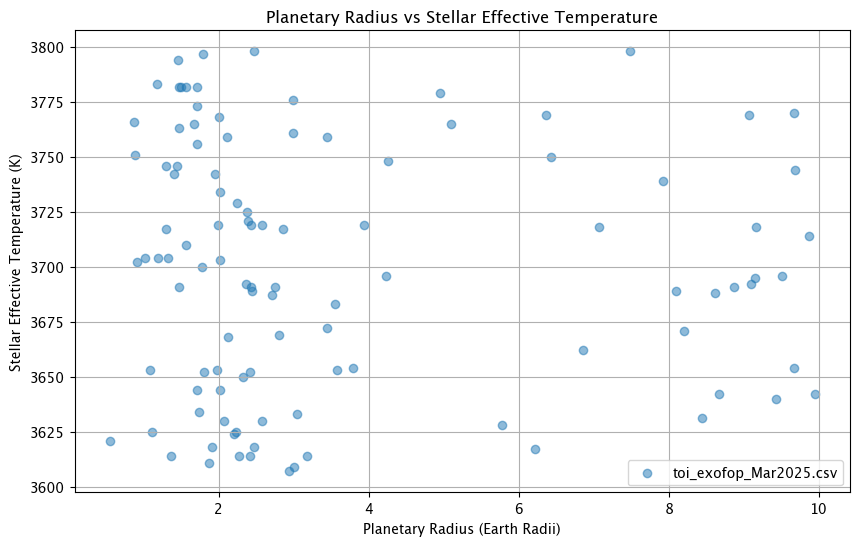

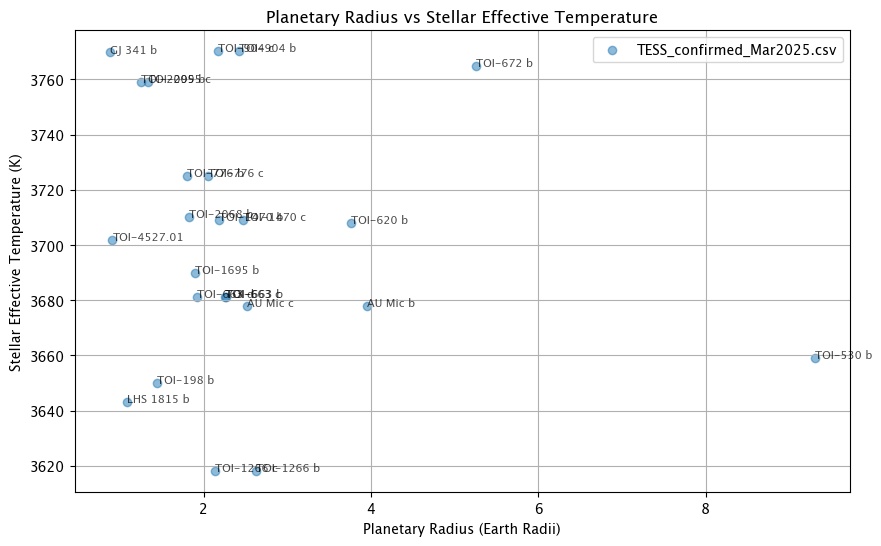

File 1: toi_exofop_Mar2025.csv
105 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
24 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2619047619047619, P-value: 0.11269589974472949
KS Statistic for 'st_teff': 0.15357142857142858, P-value: 0.6834532879670199


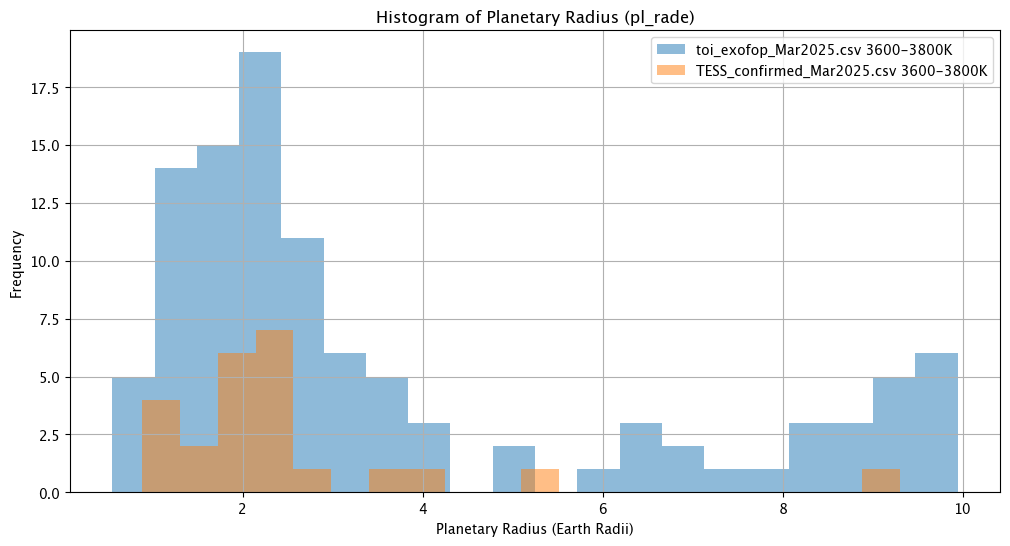

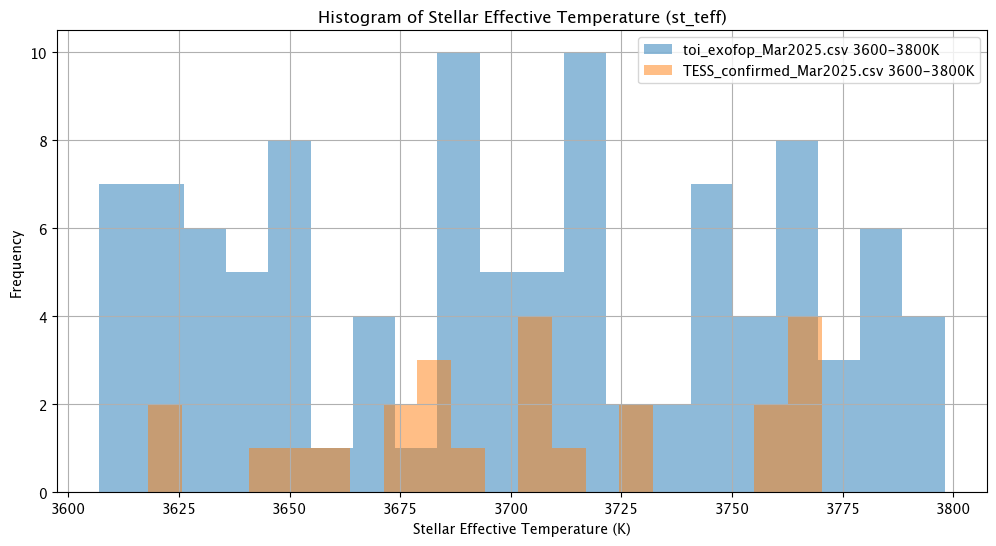

KeyError: 'pl_name'


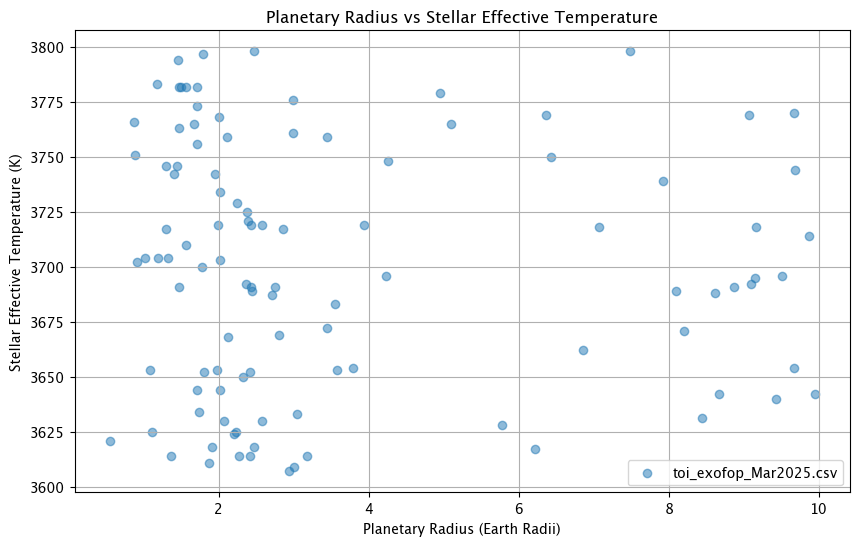

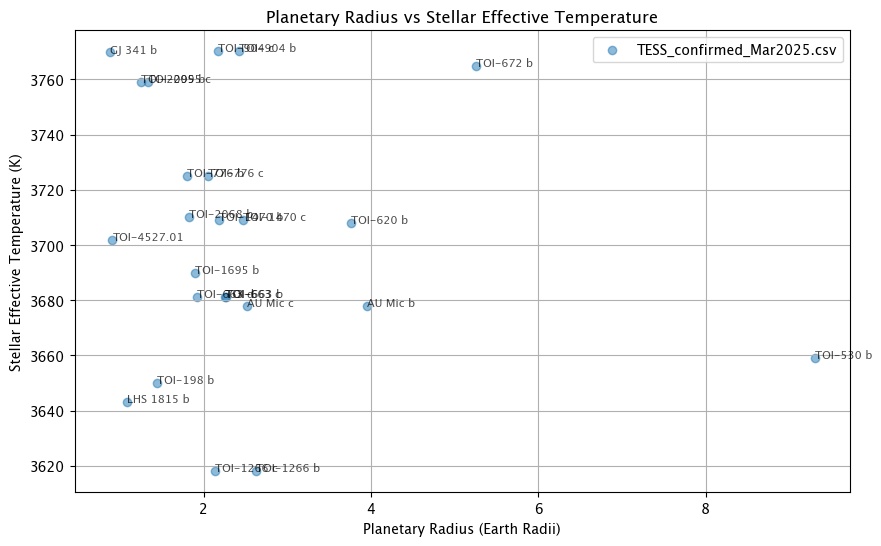

File 1: toi_exofop_Mar2025.csv
105 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
24 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2619047619047619, P-value: 0.11269589974472949
KS Statistic for 'st_teff': 0.15357142857142858, P-value: 0.6834532879670199


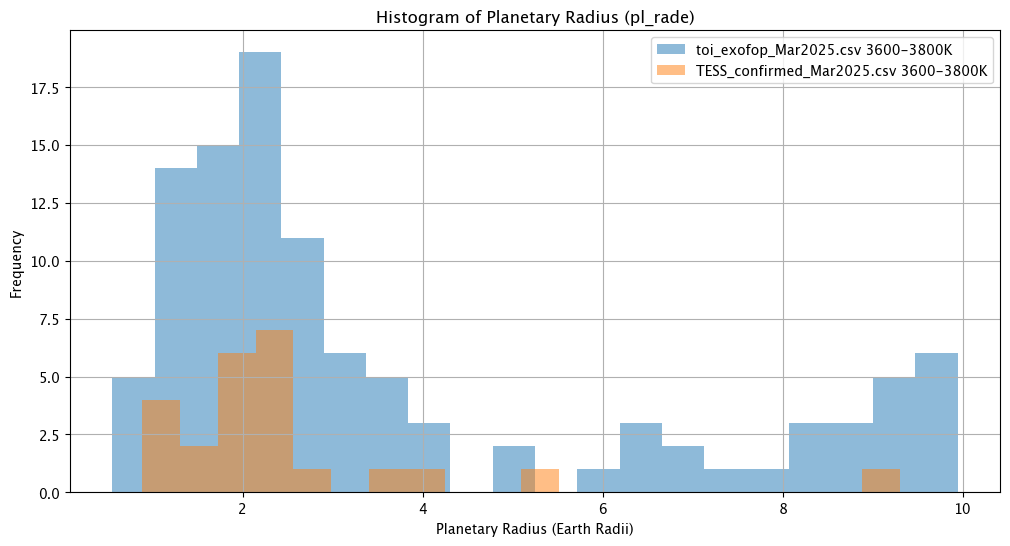

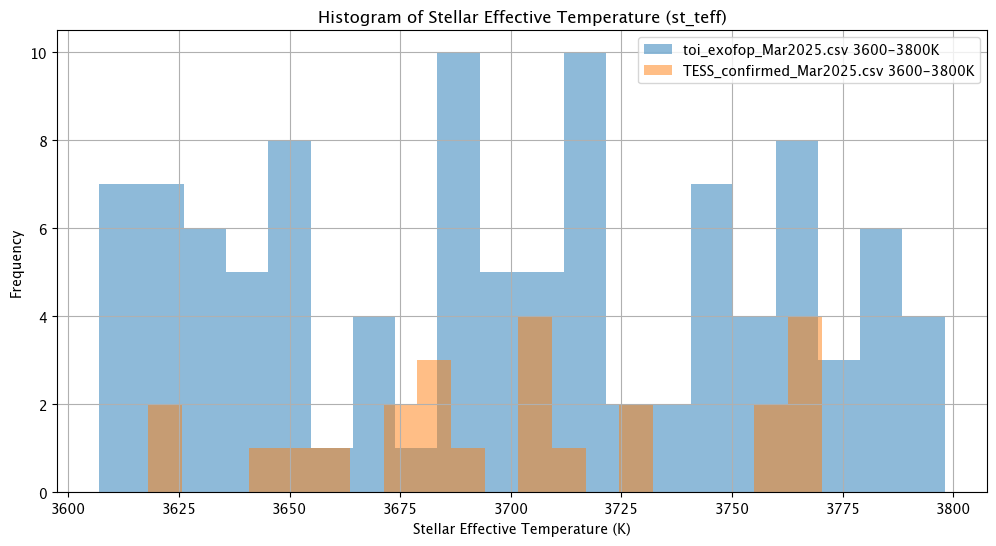

KeyError: 'pl_name'


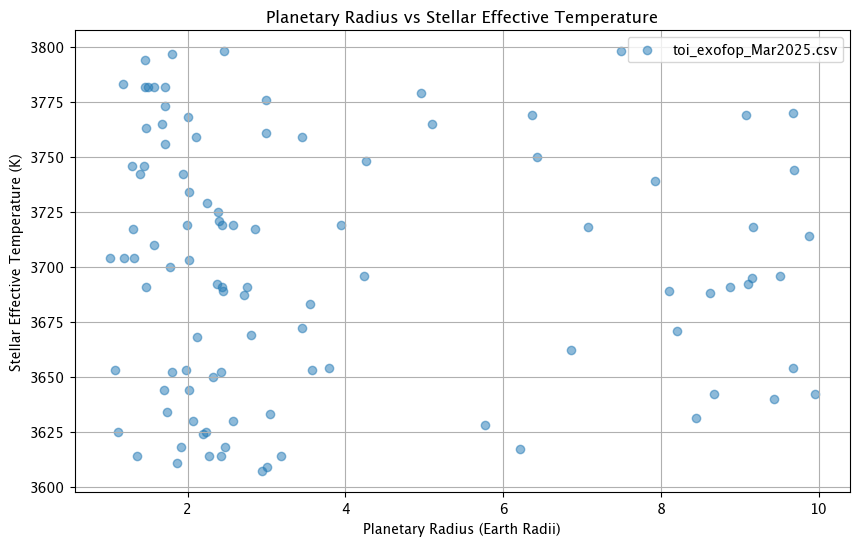

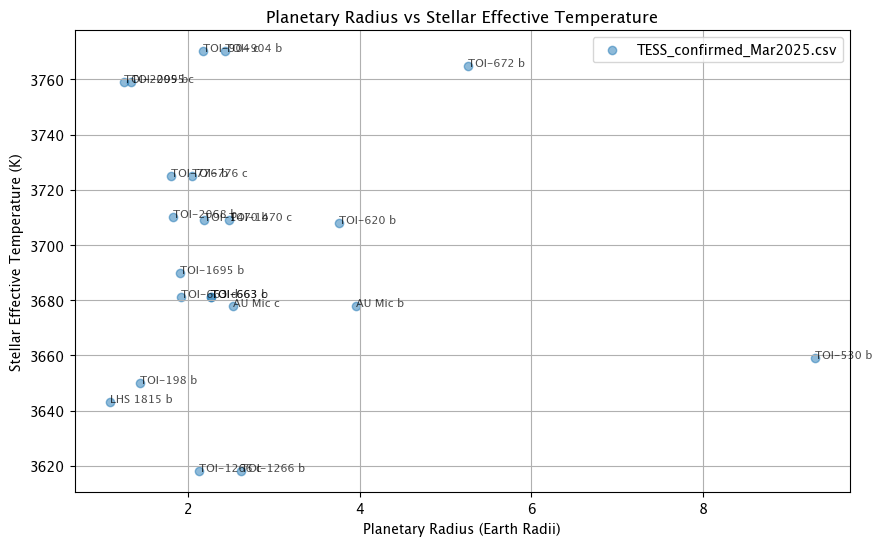

File 1: toi_exofop_Mar2025.csv
101 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
22 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.26372637263726373, P-value: 0.1332617571283754
KS Statistic for 'st_teff': 0.13906390639063906, P-value: 0.8214558929285665


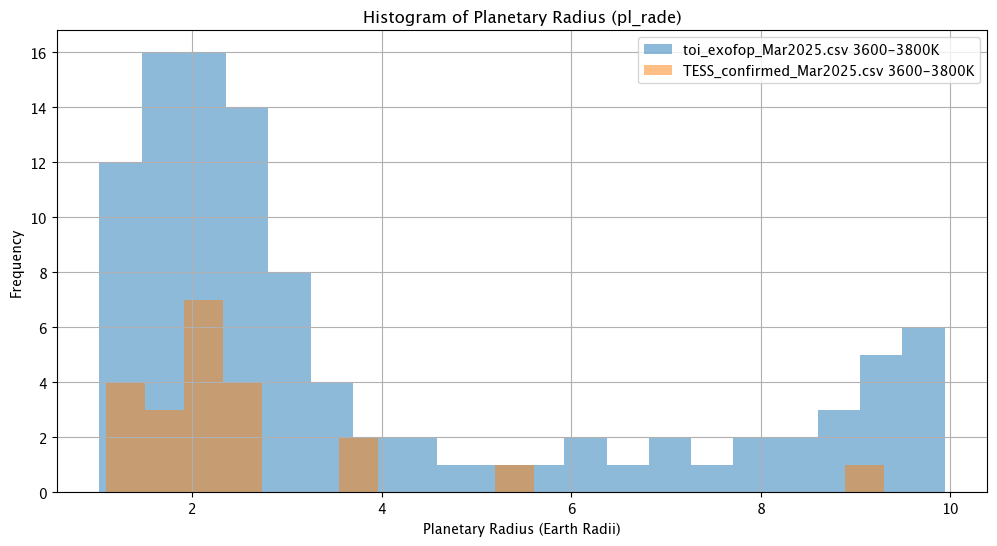

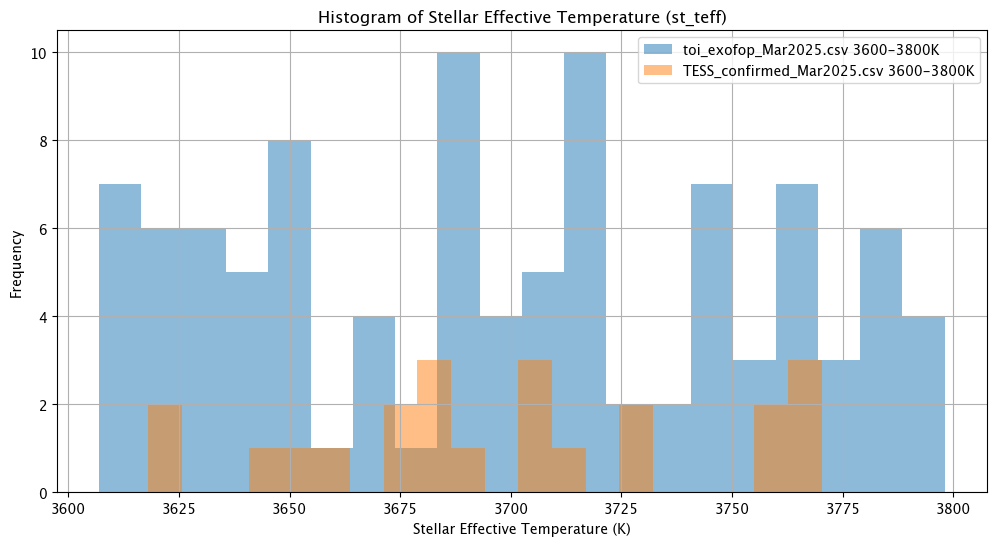

KeyError: 'pl_name'


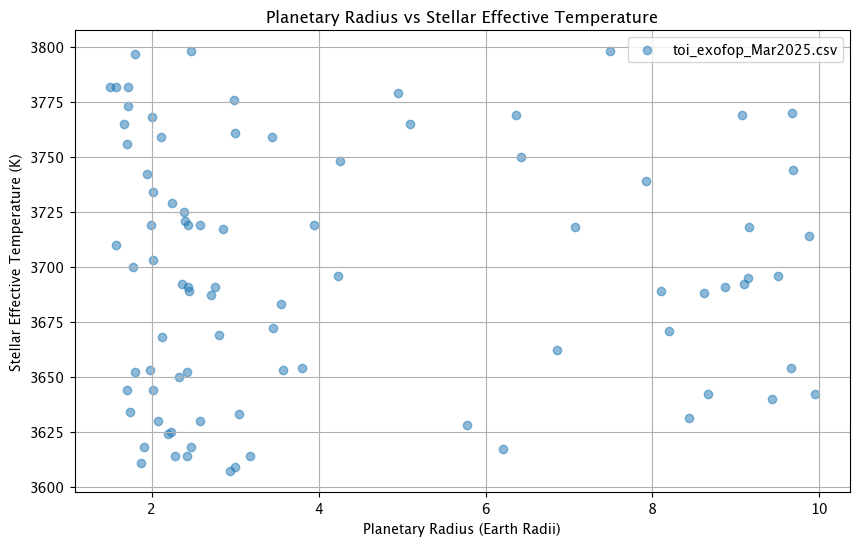

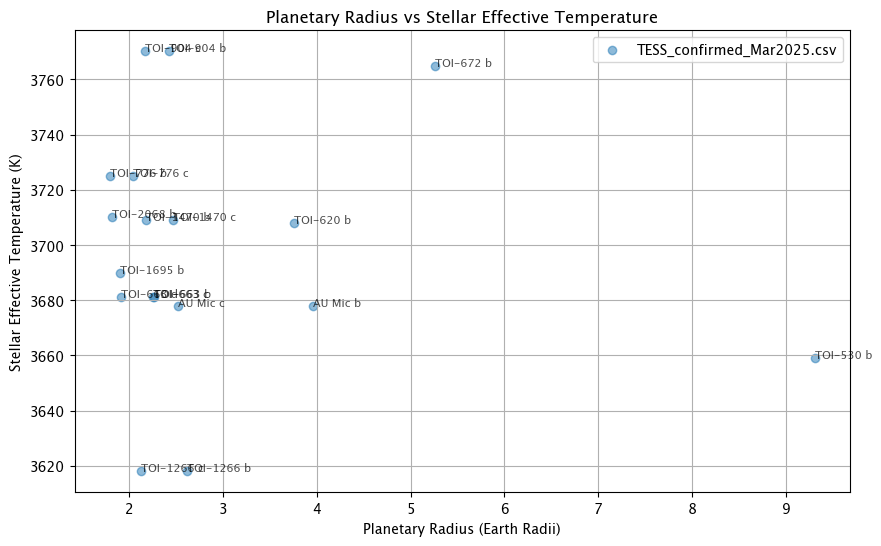

File 1: toi_exofop_Mar2025.csv
86 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
18 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.30103359173126615, P-value: 0.10718999202522128
KS Statistic for 'st_teff': 0.22868217054263565, P-value: 0.3575179089215291


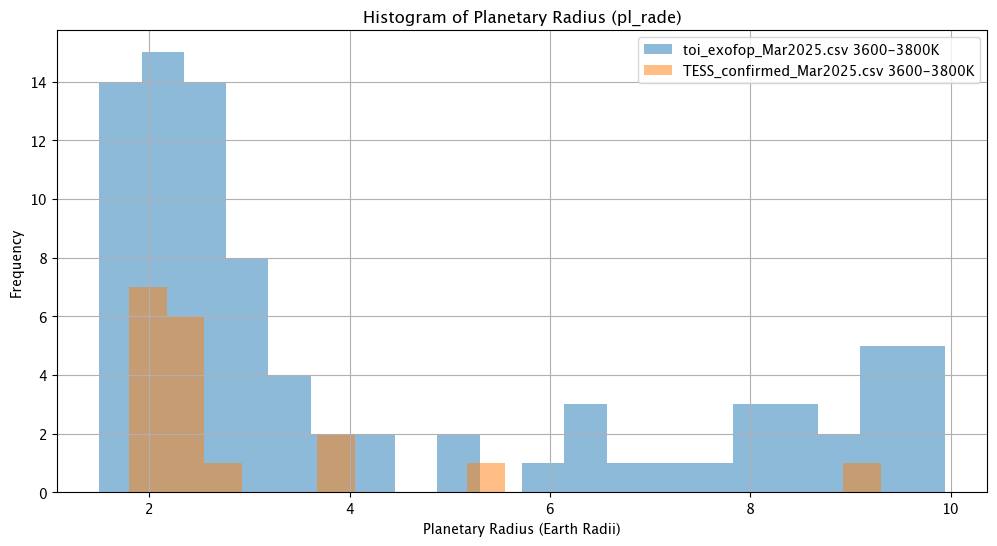

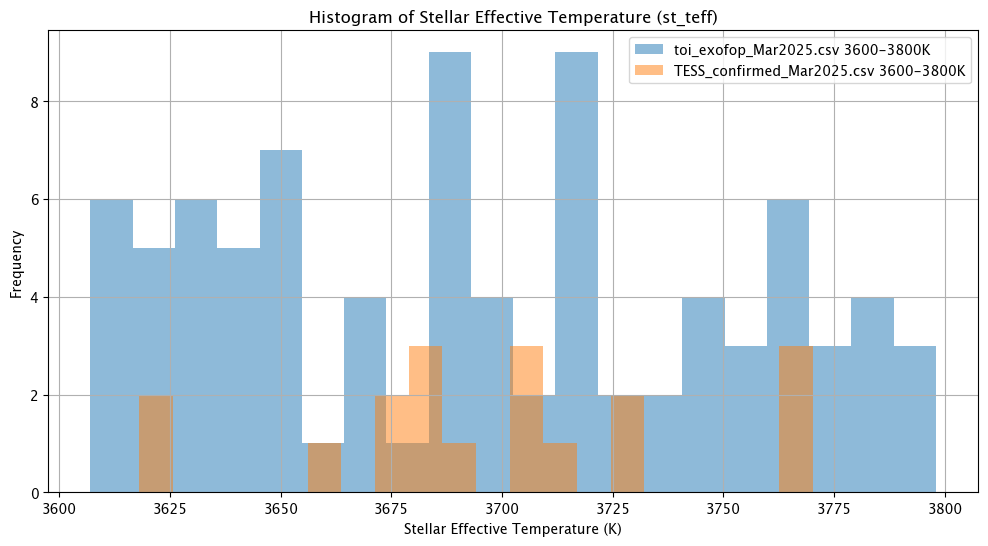

KeyError: 'pl_name'


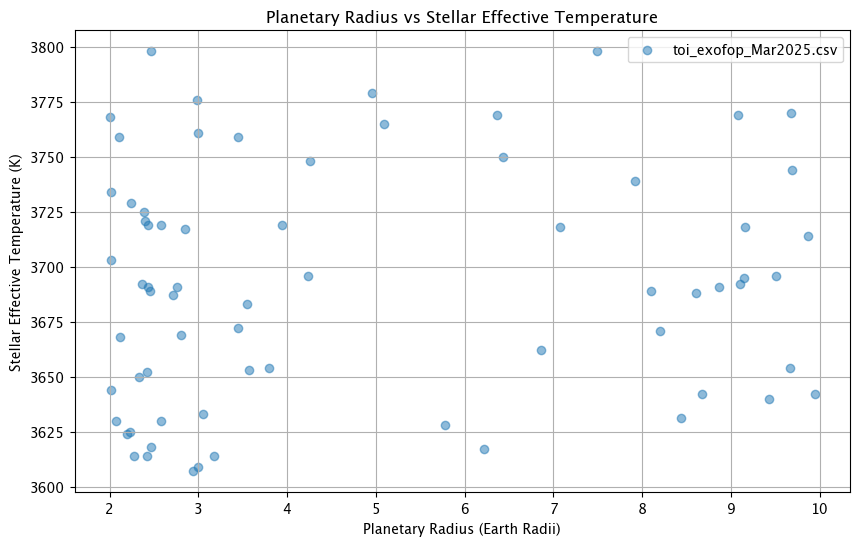

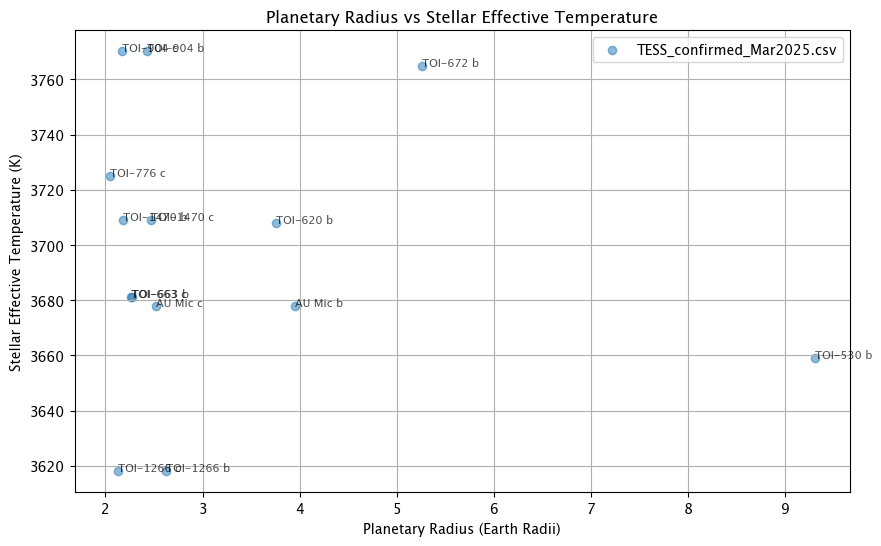

File 1: toi_exofop_Mar2025.csv
69 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
14 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.36645962732919257, P-value: 0.0653435088609402
KS Statistic for 'st_teff': 0.1915113871635611, P-value: 0.7131390794970476


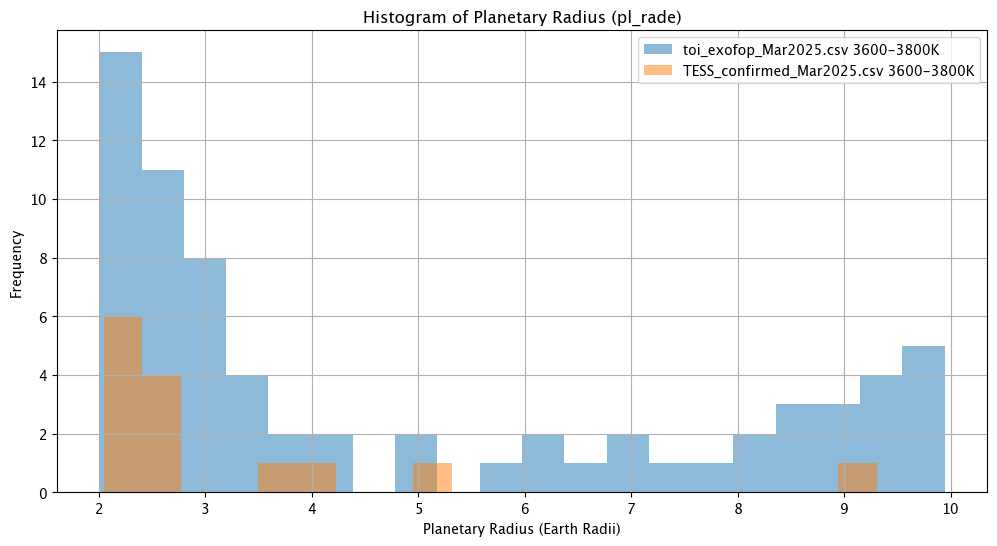

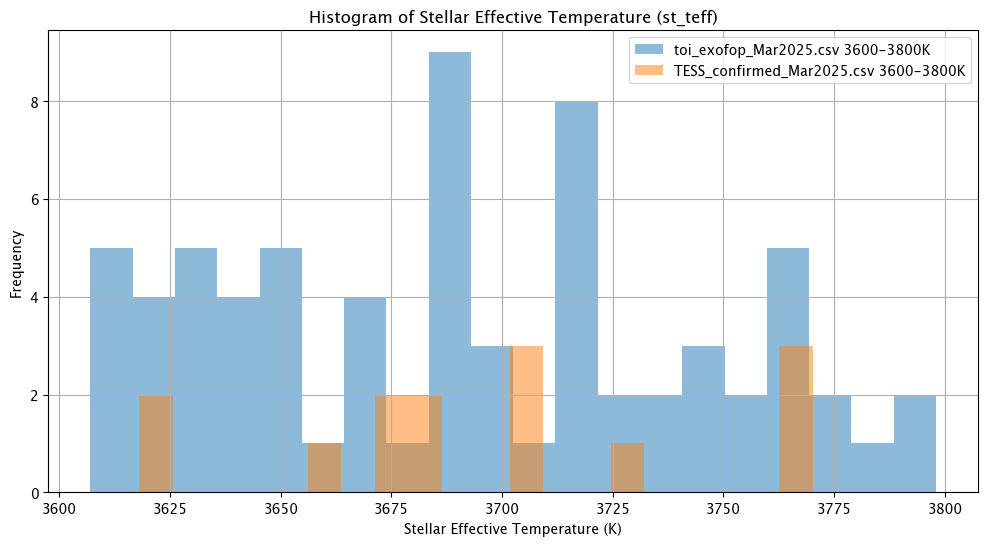

KeyError: 'pl_name'


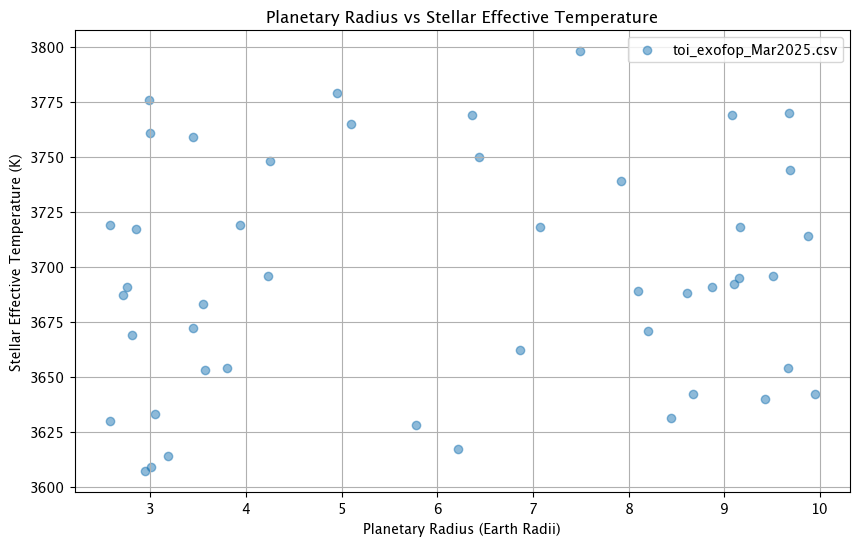

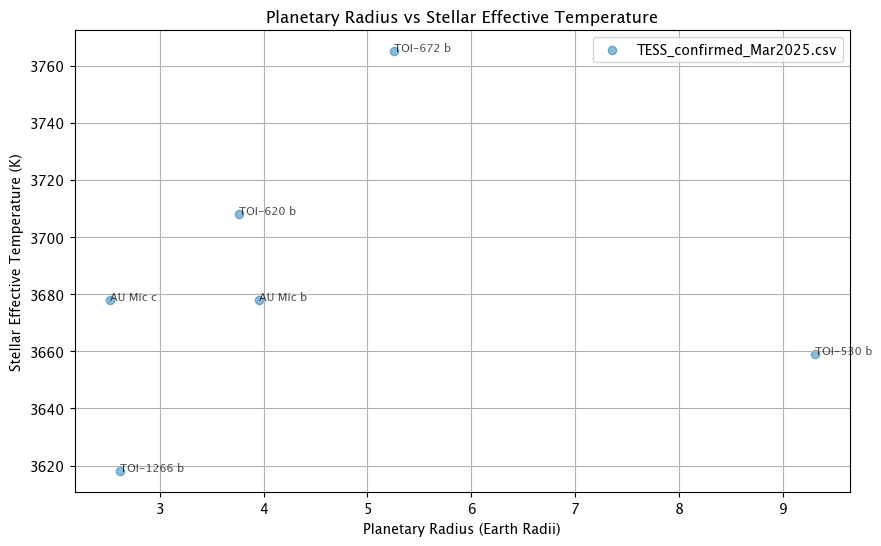

File 1: toi_exofop_Mar2025.csv
47 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
6 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.36524822695035464, P-value: 0.3843073368679838
KS Statistic for 'st_teff': 0.28368794326241137, P-value: 0.6873653380074817


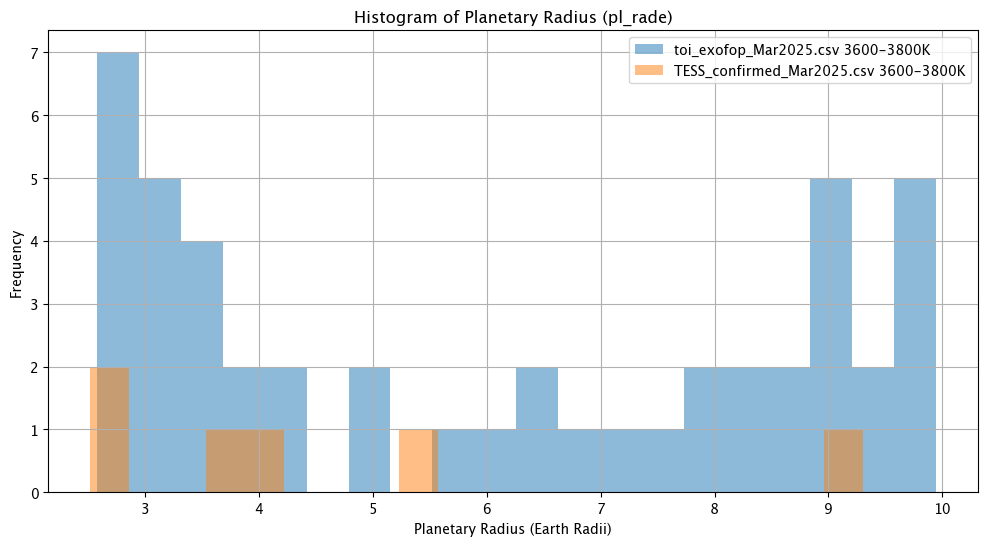

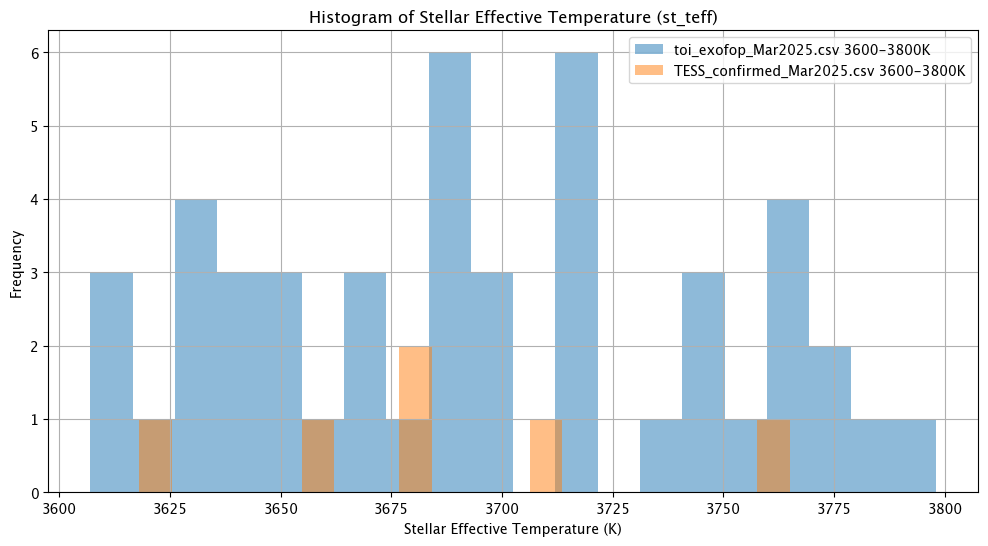

KeyError: 'pl_name'


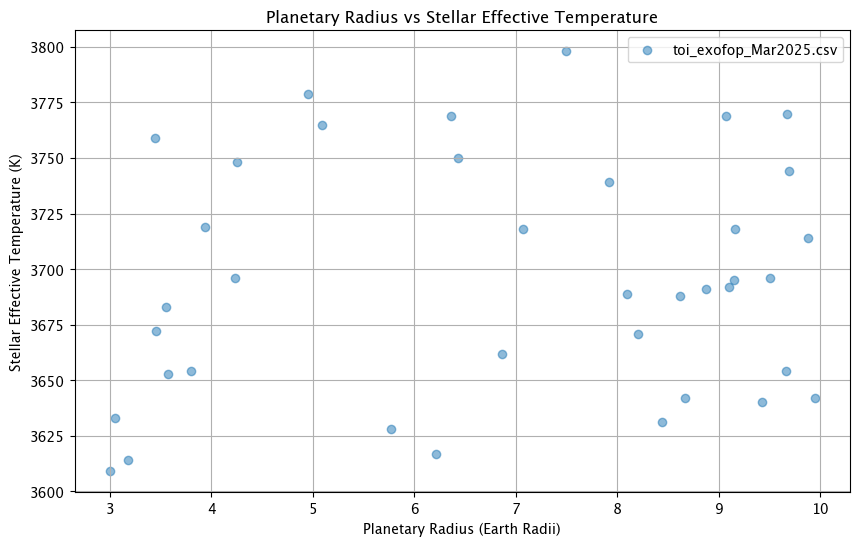

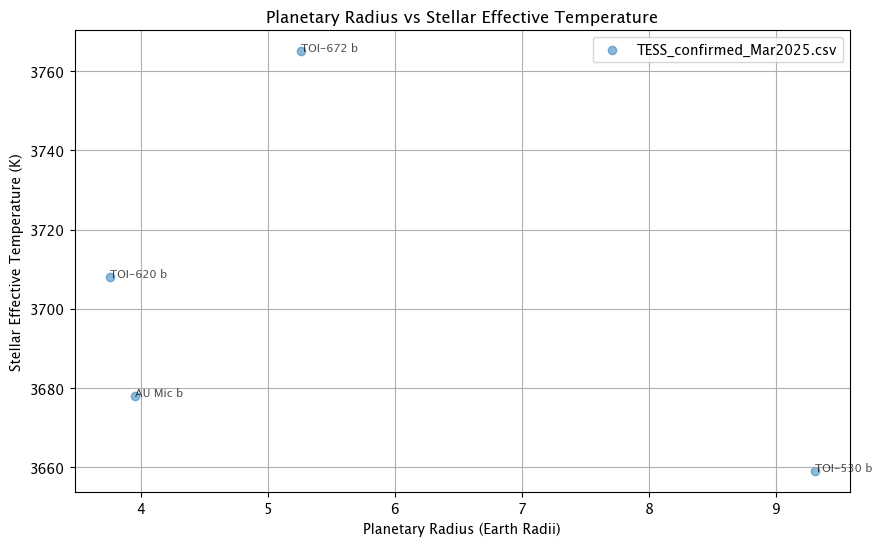

File 1: toi_exofop_Mar2025.csv
38 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
4 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.40789473684210525, P-value: 0.4744929866881087
KS Statistic for 'st_teff': 0.3157894736842105, P-value: 0.778397212543554


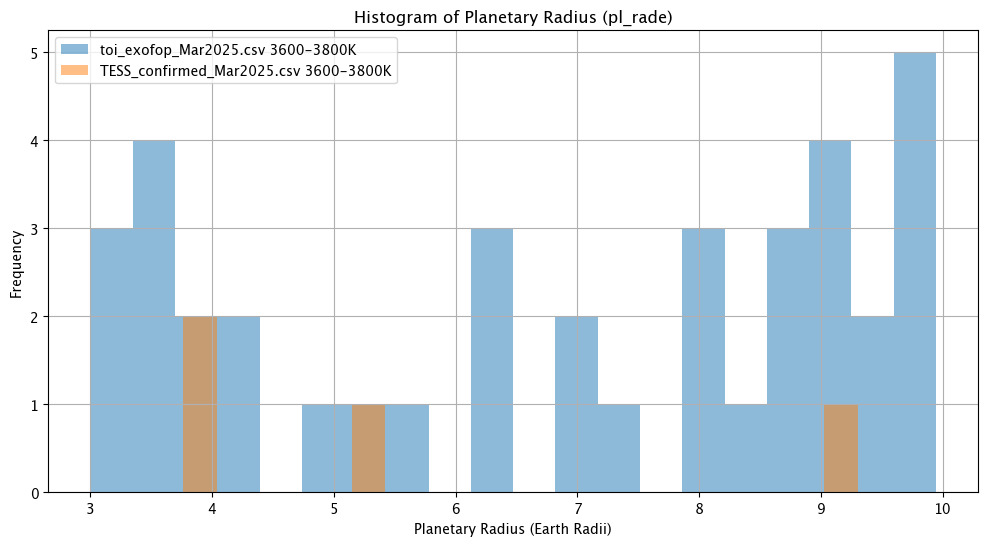

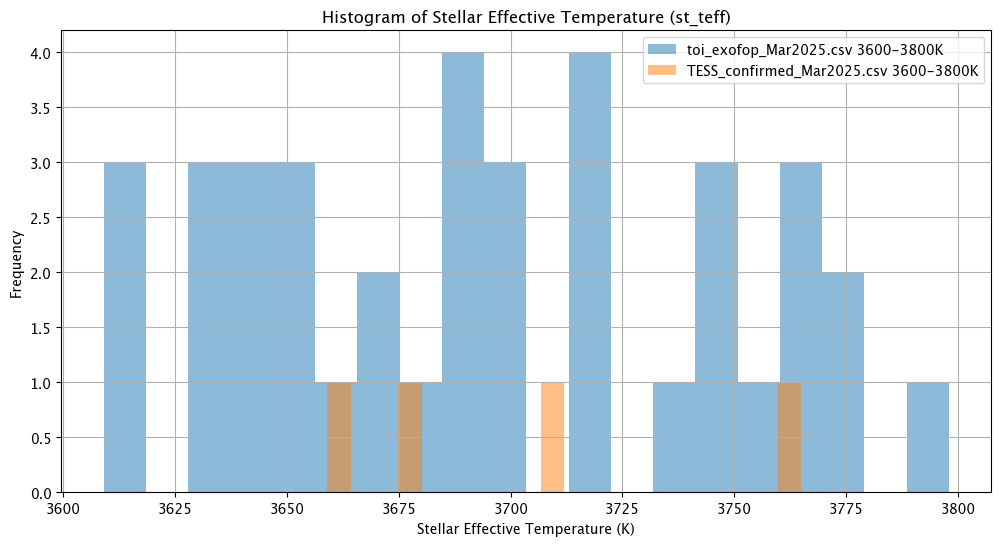

KeyError: 'pl_name'


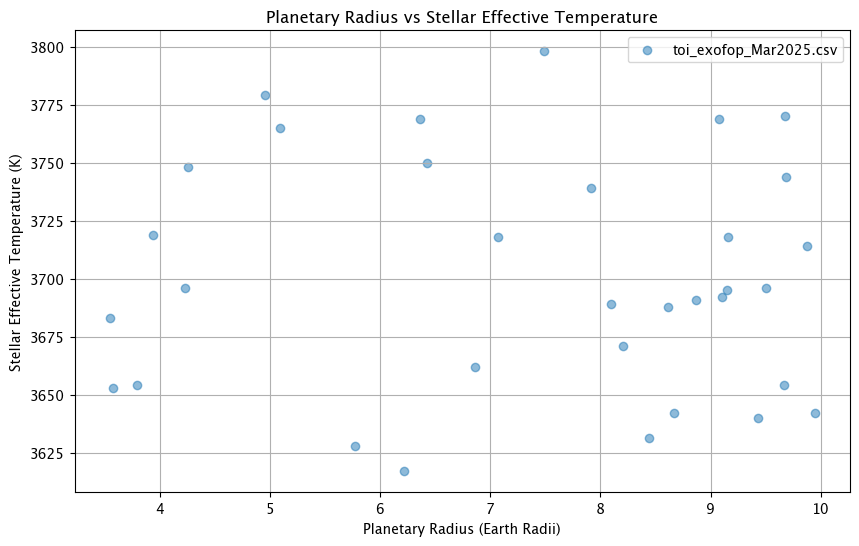

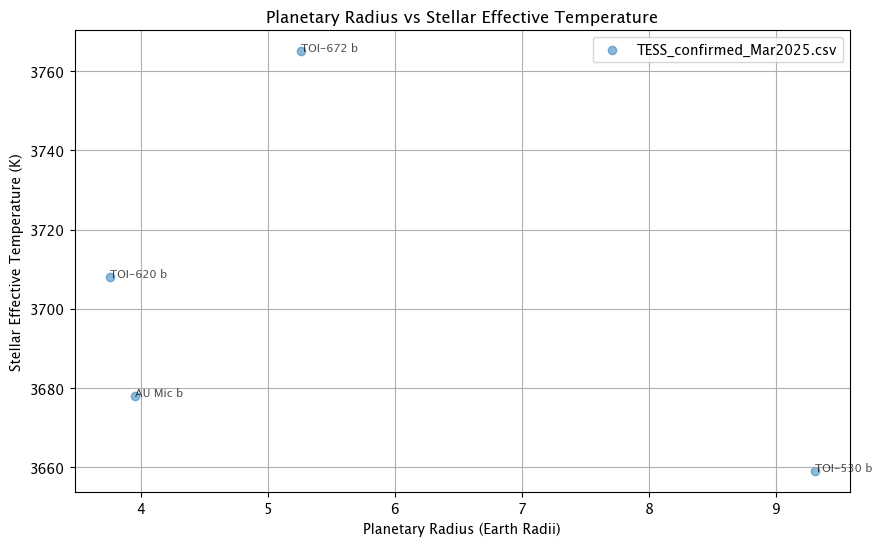

File 1: toi_exofop_Mar2025.csv
33 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
4 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.5075757575757576, P-value: 0.23166023166023164
KS Statistic for 'st_teff': 0.2727272727272727, P-value: 0.8785827844651374


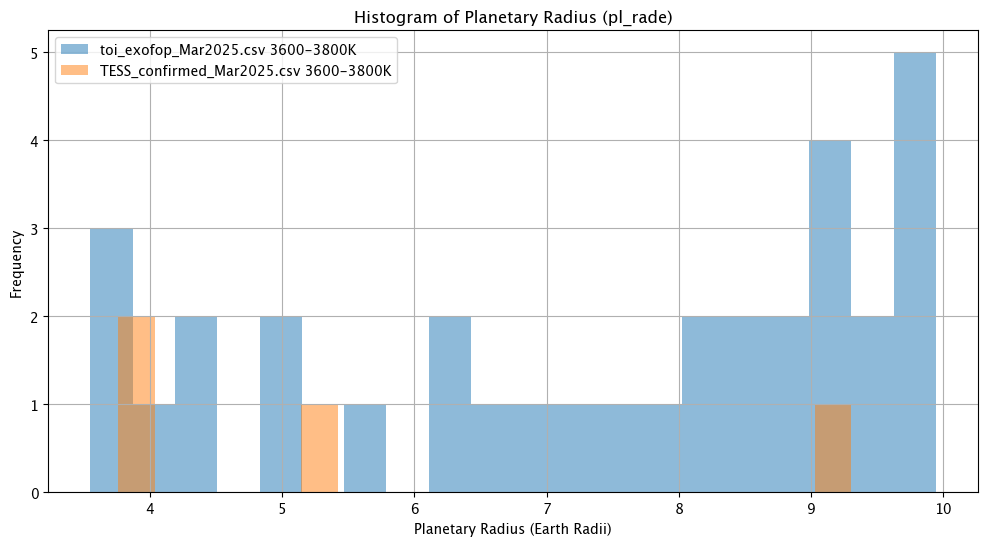

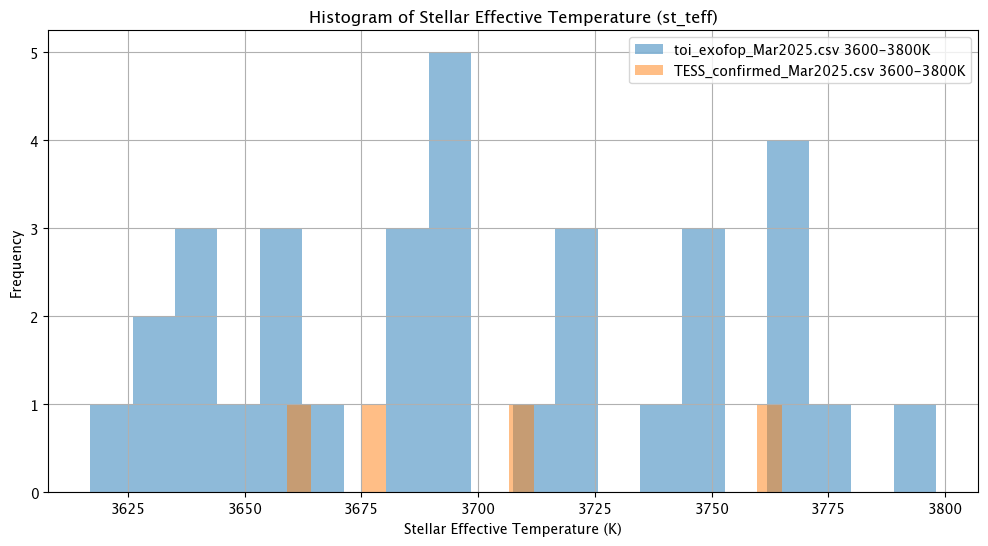

KeyError: 'pl_name'


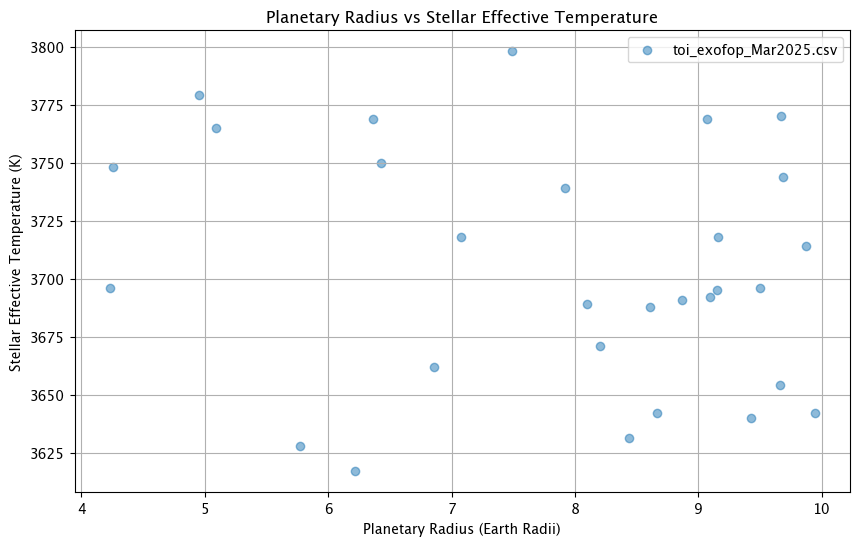

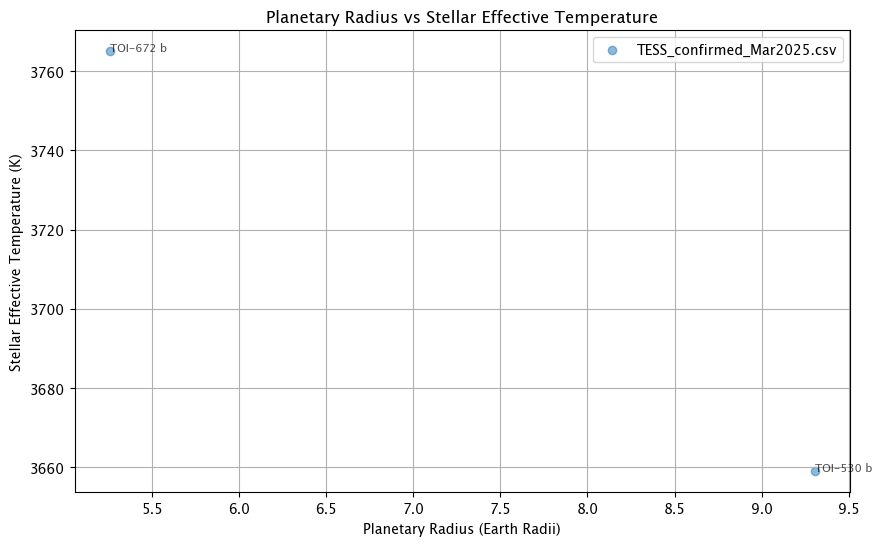

File 1: toi_exofop_Mar2025.csv
29 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
2 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.3620689655172414, P-value: 0.9225806451612903
KS Statistic for 'st_teff': 0.29310344827586204, P-value: 0.9913978494623656


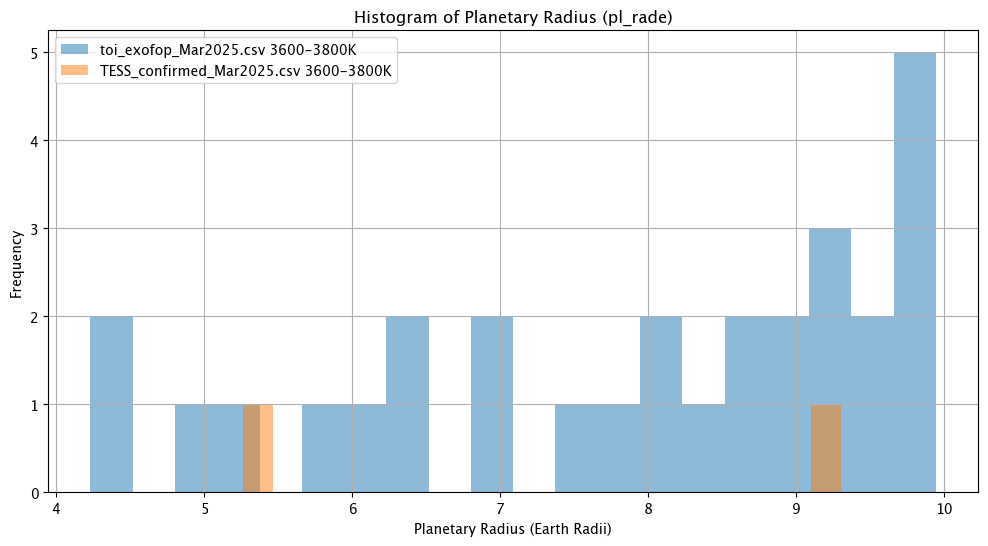

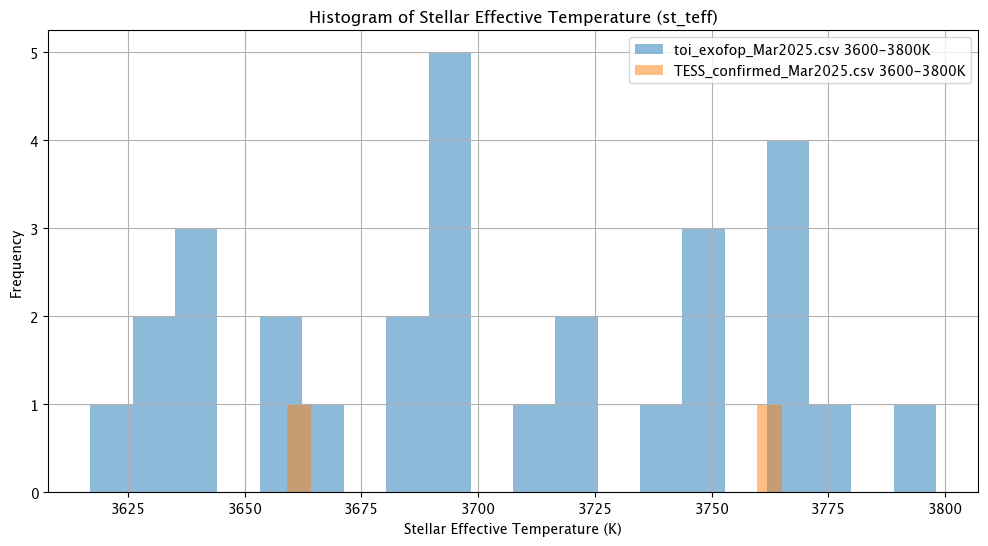

KeyError: 'pl_name'


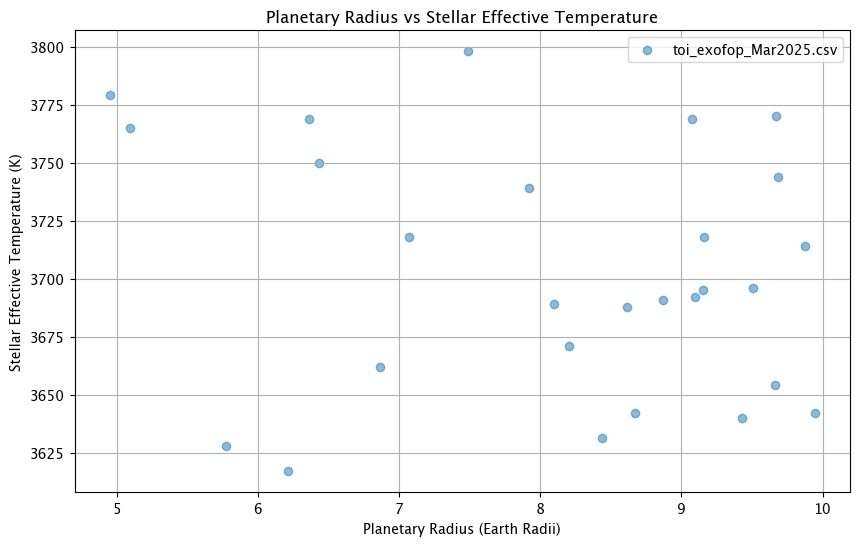

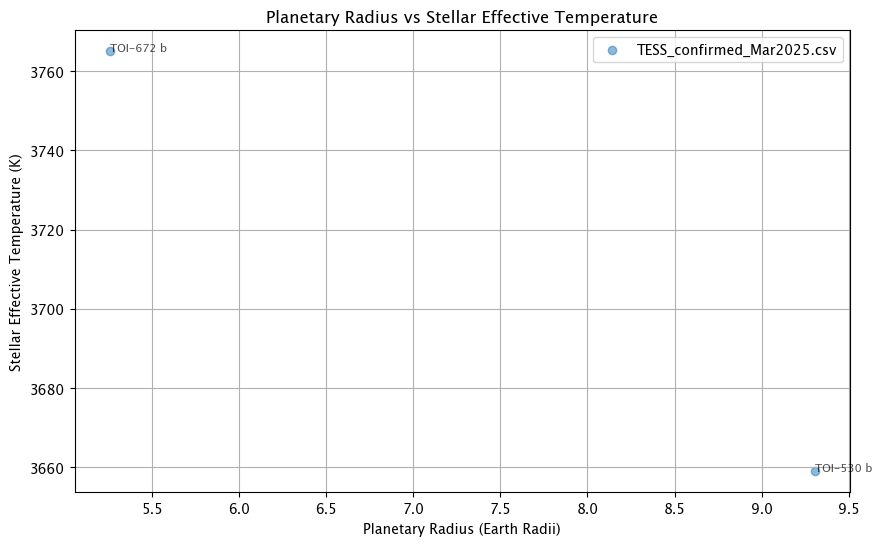

File 1: toi_exofop_Mar2025.csv
27 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
2 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.42592592592592593, P-value: 0.8004926108374384
KS Statistic for 'st_teff': 0.2777777777777778, P-value: 0.9975369458128078


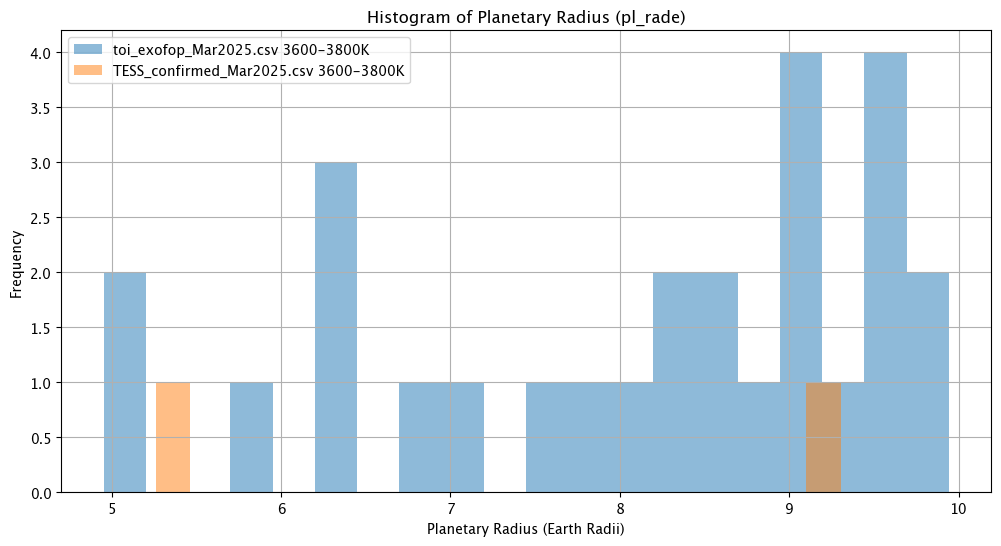

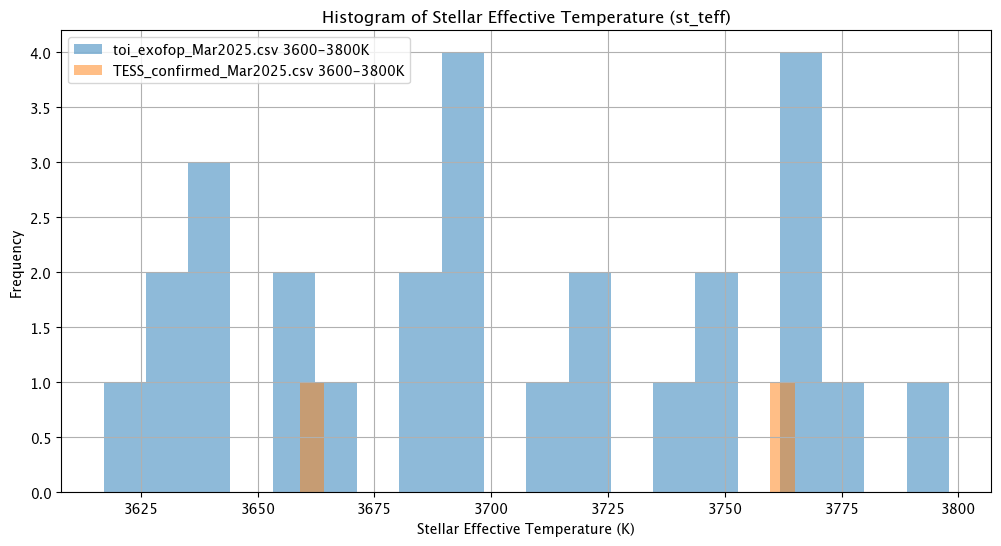

KeyError: 'pl_name'


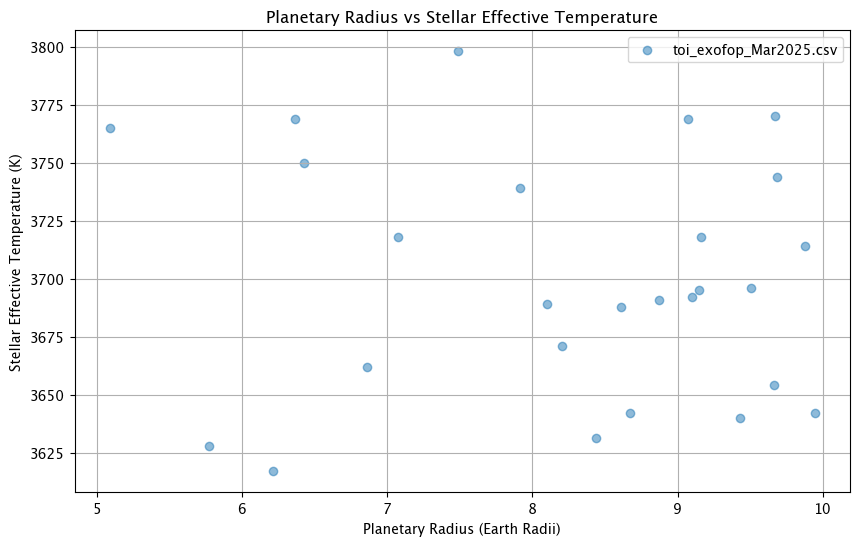

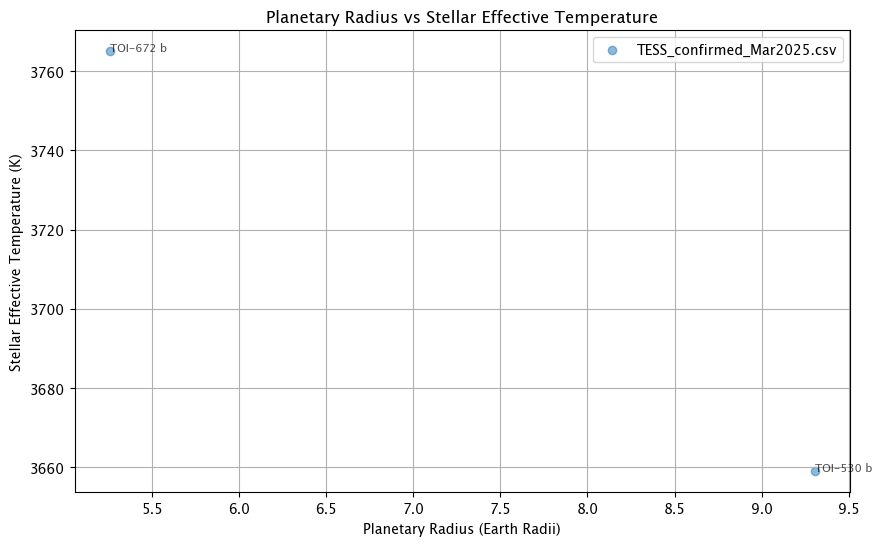

File 1: toi_exofop_Mar2025.csv
26 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
2 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.46153846153846156, P-value: 0.7354497354497355
KS Statistic for 'st_teff': 0.3076923076923077, P-value: 0.9894179894179894


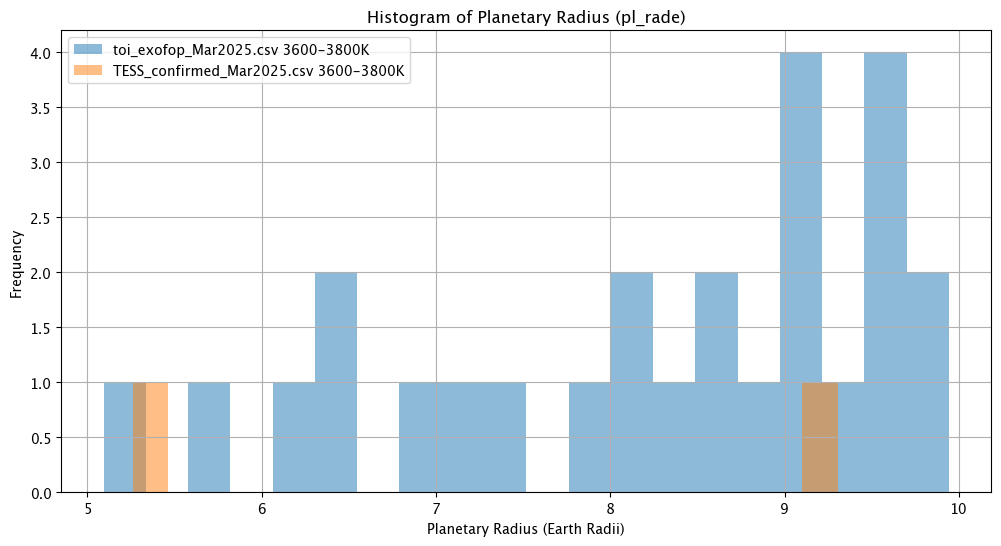

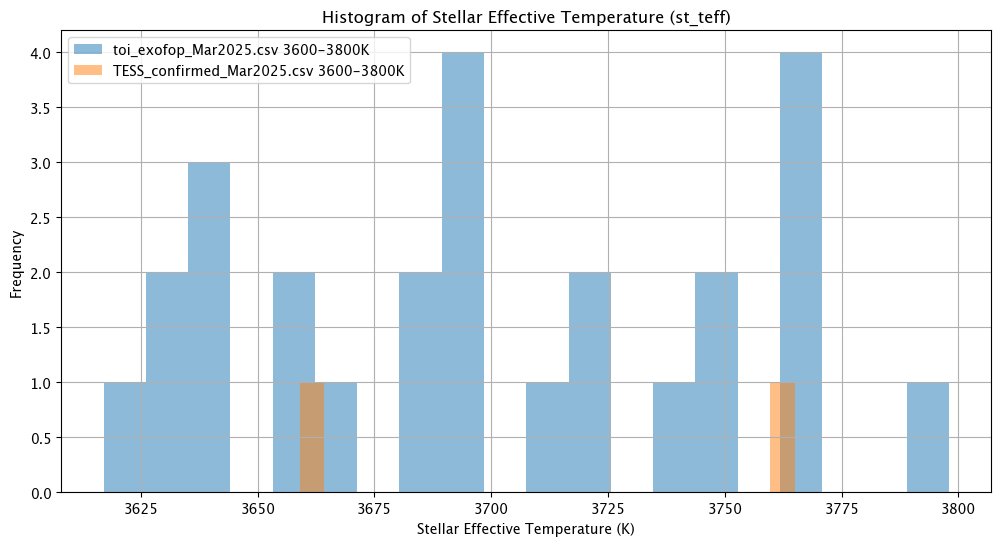

KeyError: 'pl_name'


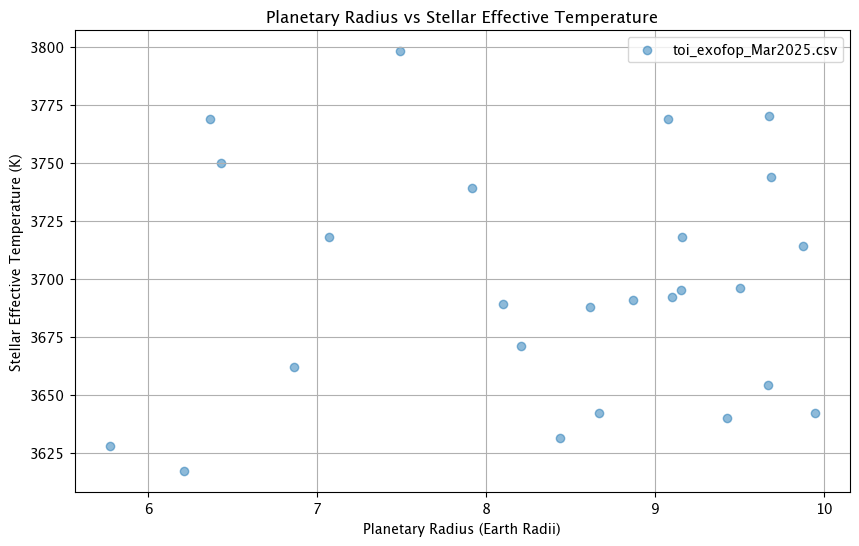

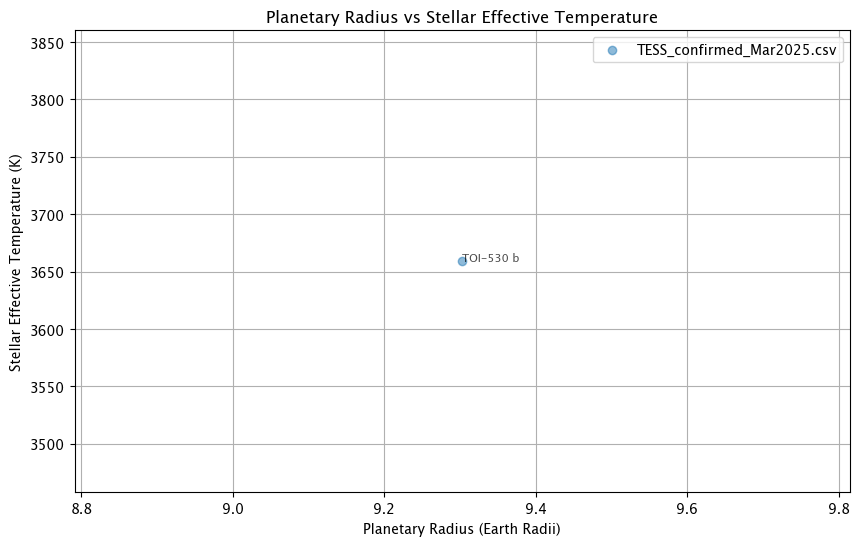

File 1: toi_exofop_Mar2025.csv
25 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.72, P-value: 0.6153846153846154
KS Statistic for 'st_teff': 0.72, P-value: 0.6153846153846154


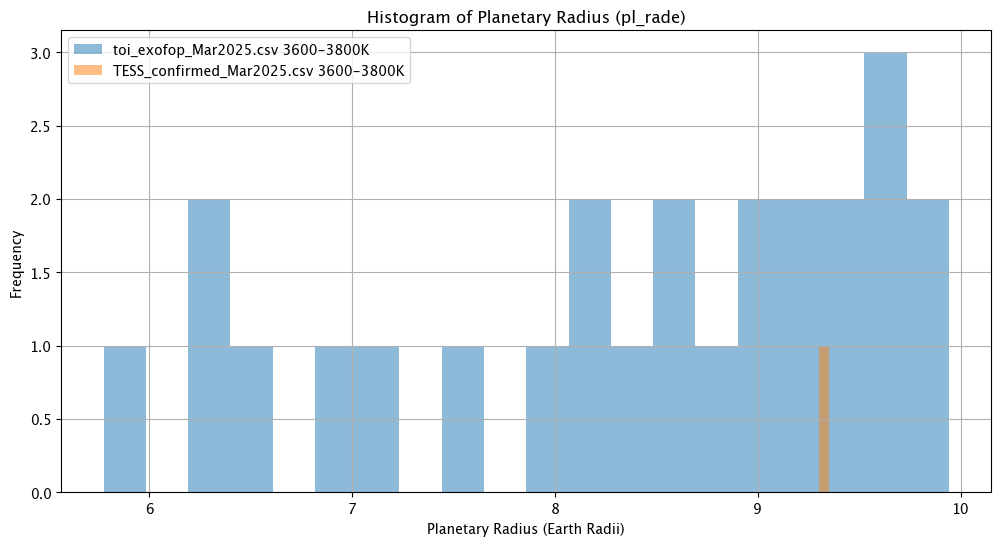

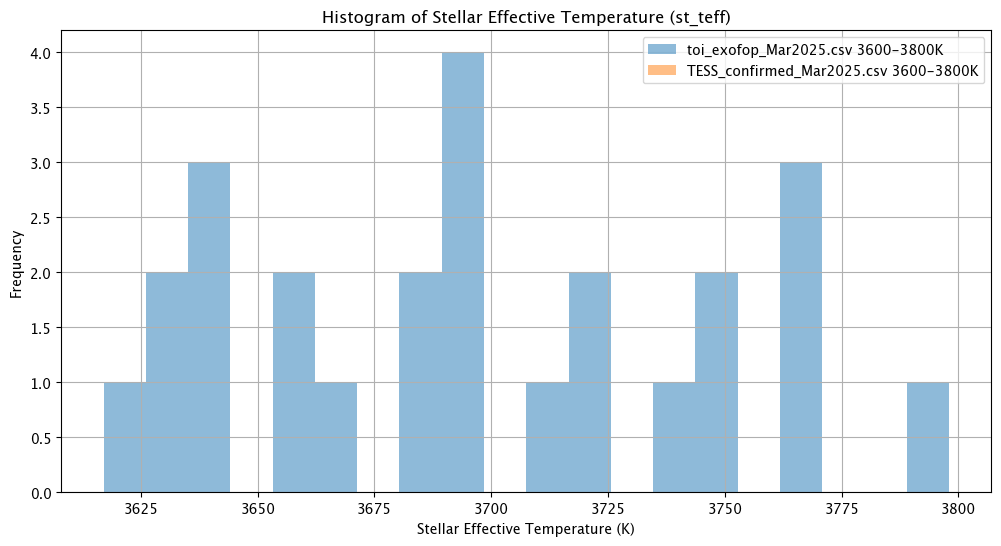

KeyError: 'pl_name'


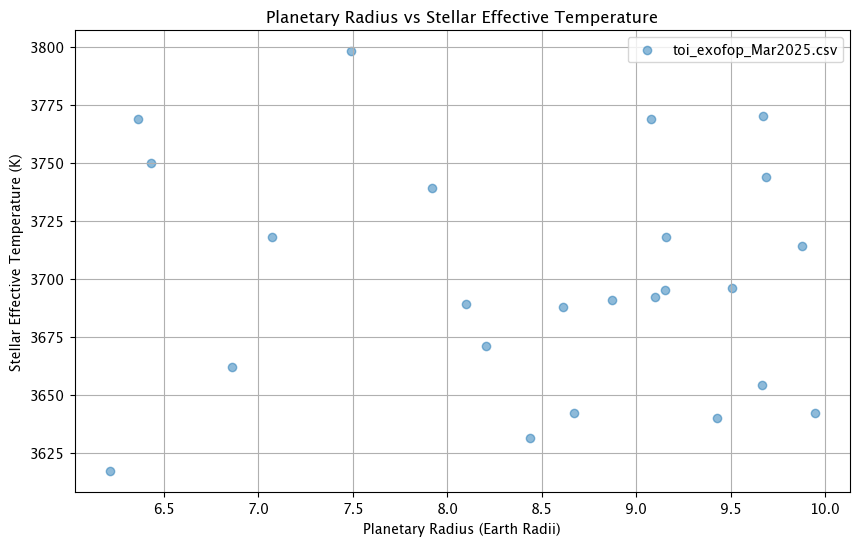

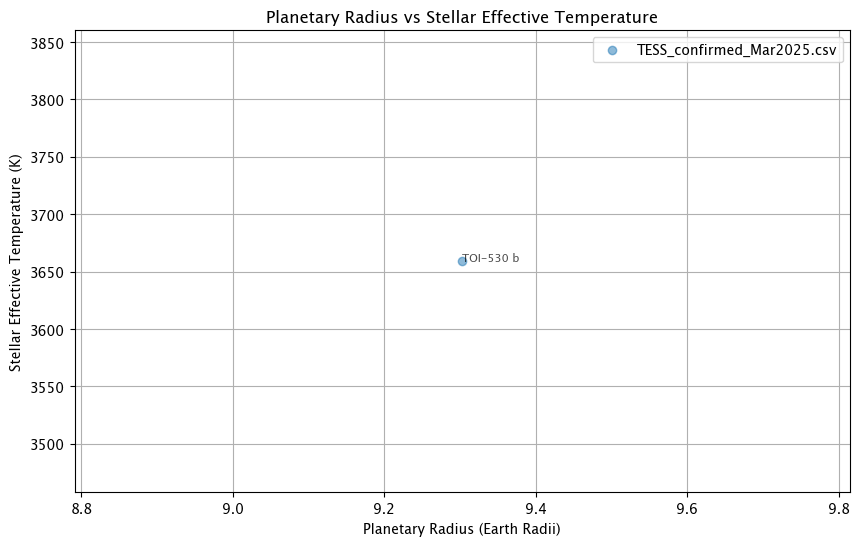

File 1: toi_exofop_Mar2025.csv
24 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.7083333333333334, P-value: 0.64
KS Statistic for 'st_teff': 0.75, P-value: 0.56


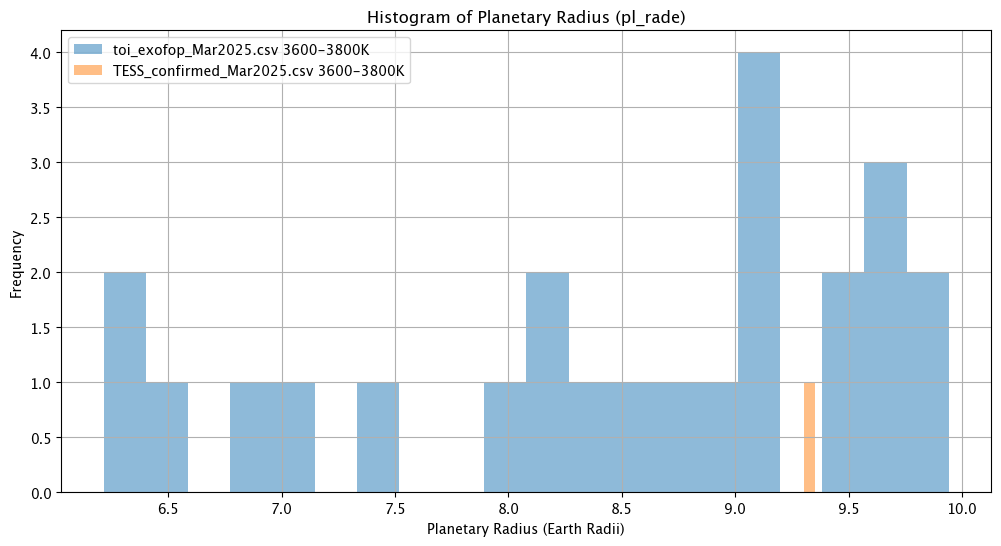

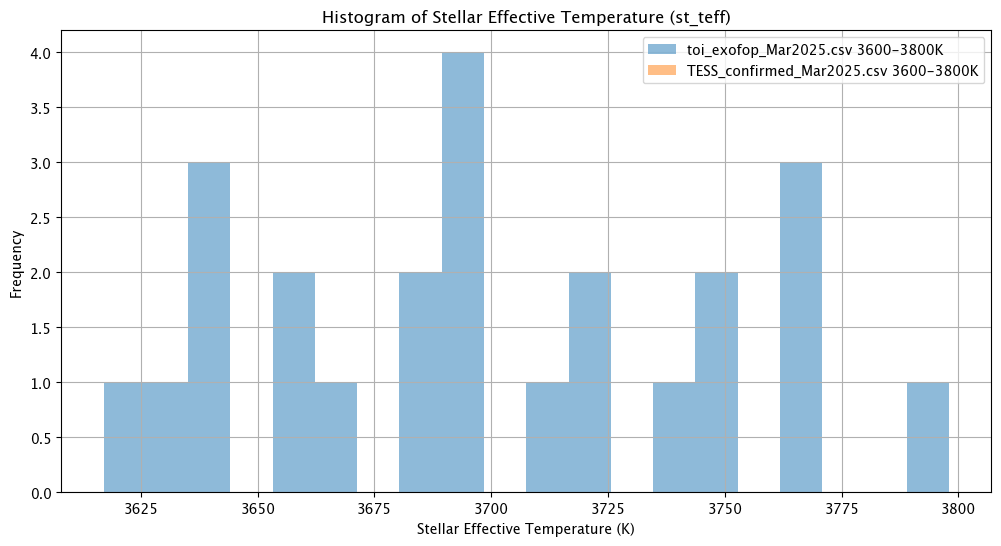

KeyError: 'pl_name'


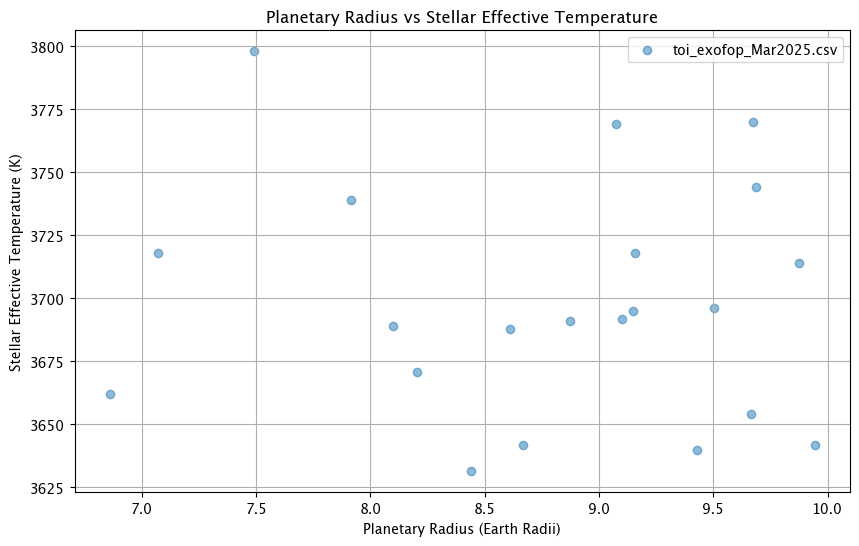

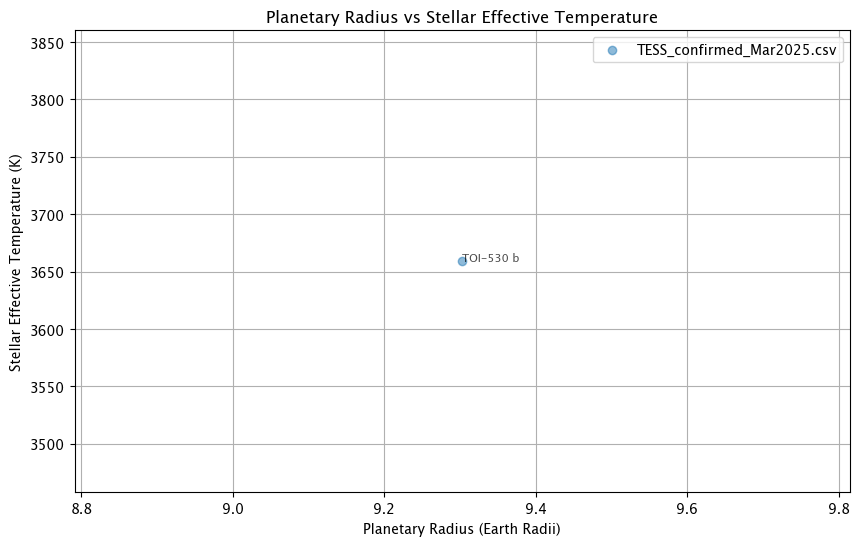

File 1: toi_exofop_Mar2025.csv
21 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.6666666666666666, P-value: 0.7272727272727273
KS Statistic for 'st_teff': 0.7619047619047619, P-value: 0.5454545454545454


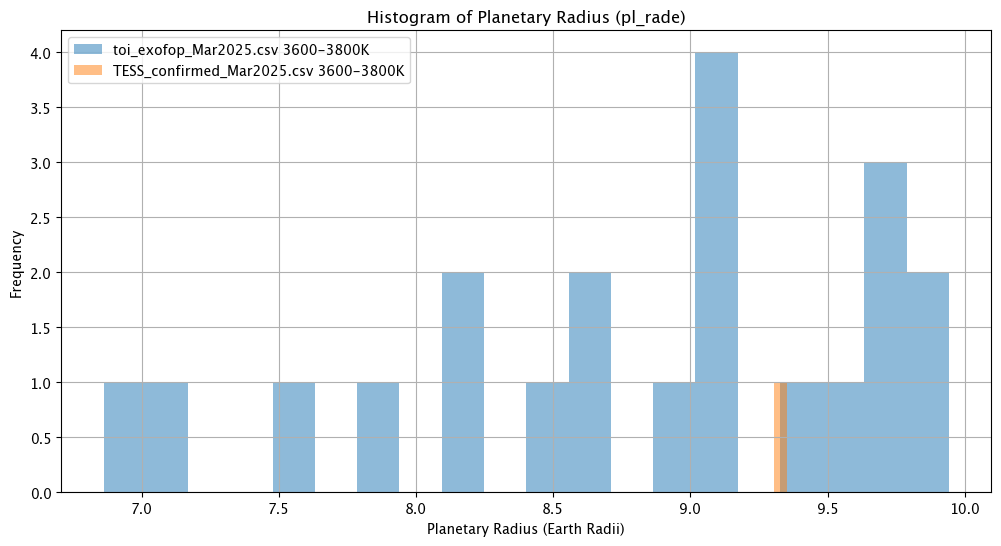

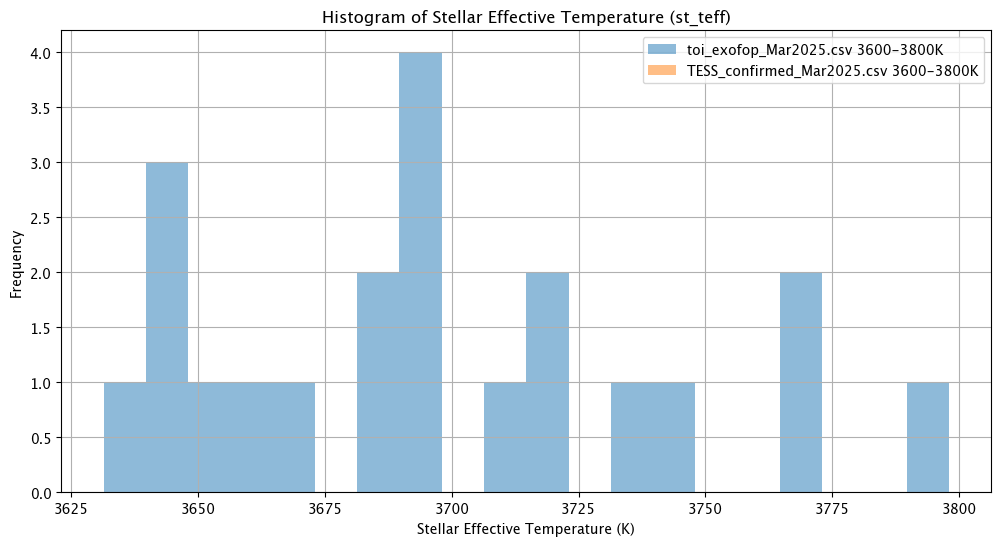

KeyError: 'pl_name'


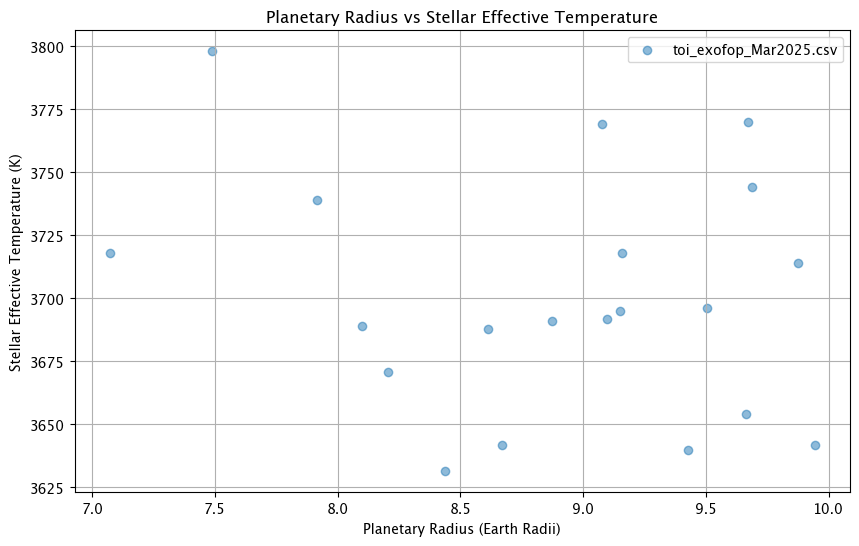

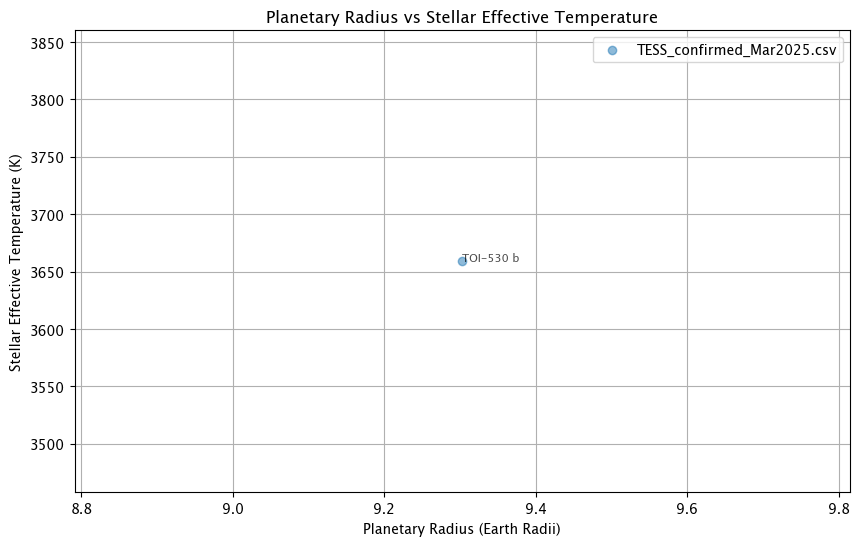

File 1: toi_exofop_Mar2025.csv
20 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.65, P-value: 0.7619047619047619
KS Statistic for 'st_teff': 0.75, P-value: 0.5714285714285714


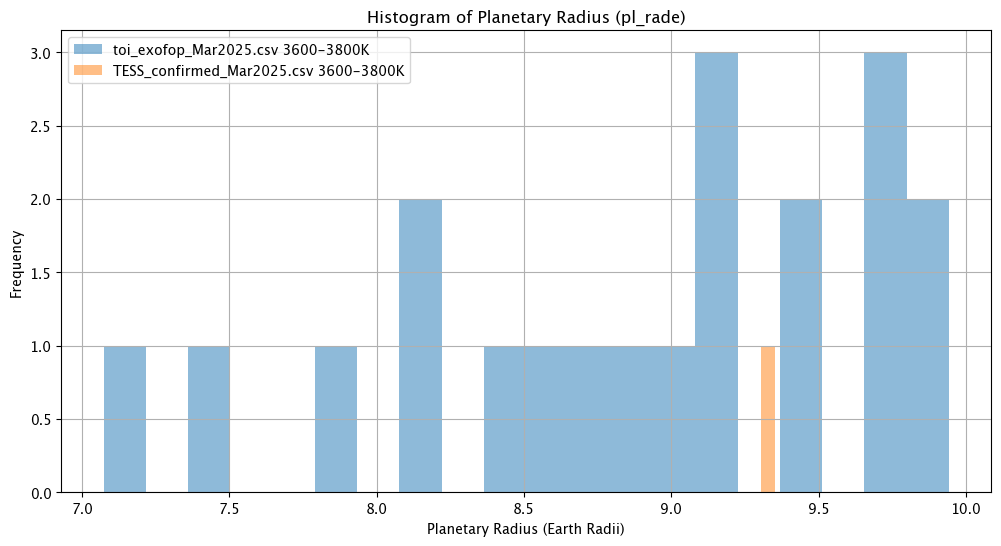

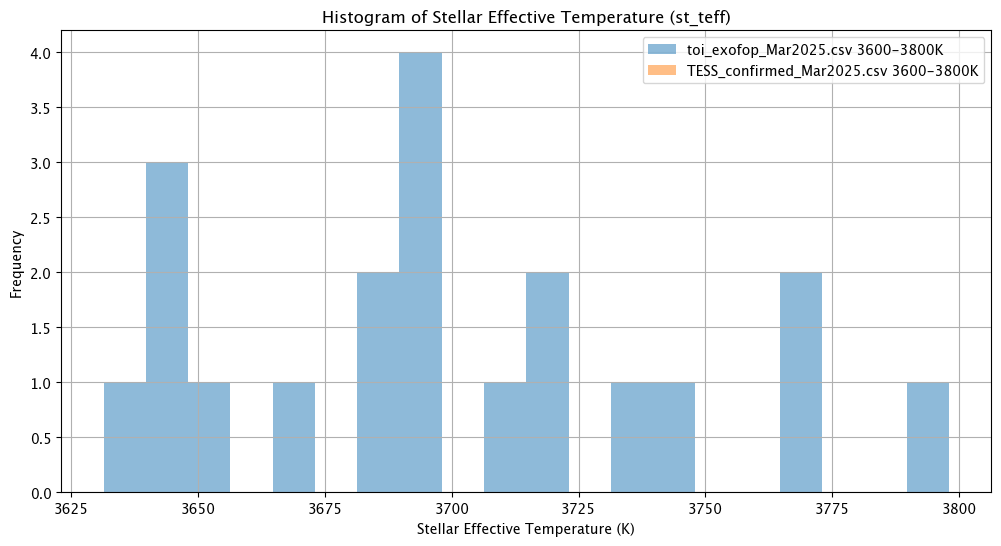

KeyError: 'pl_name'


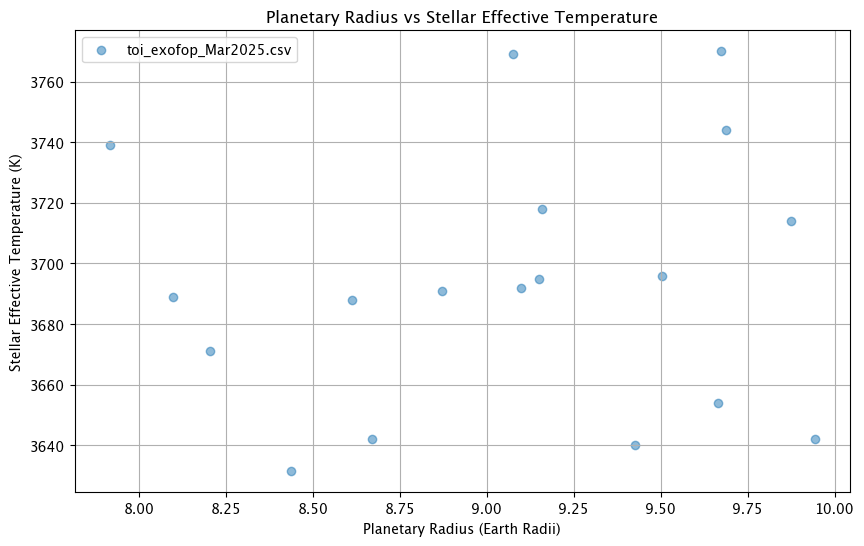

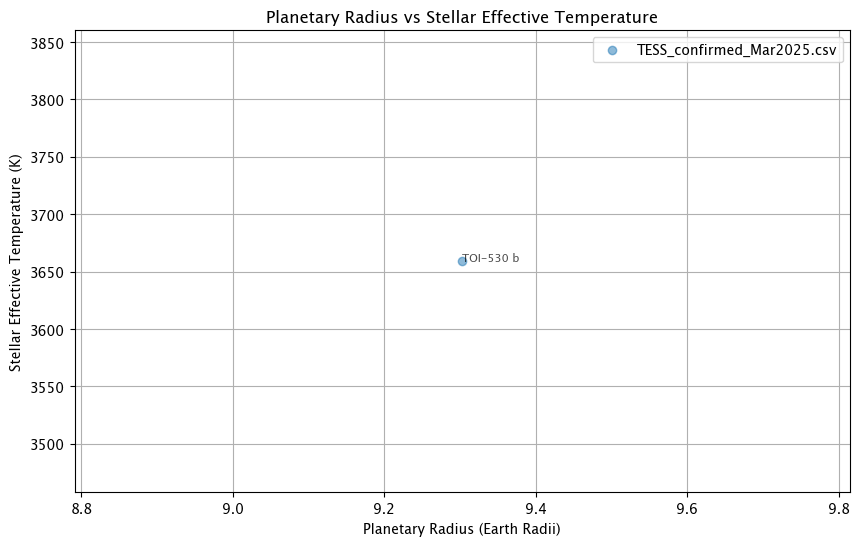

File 1: toi_exofop_Mar2025.csv
18 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.6111111111111112, P-value: 0.8421052631578947
KS Statistic for 'st_teff': 0.7222222222222222, P-value: 0.631578947368421


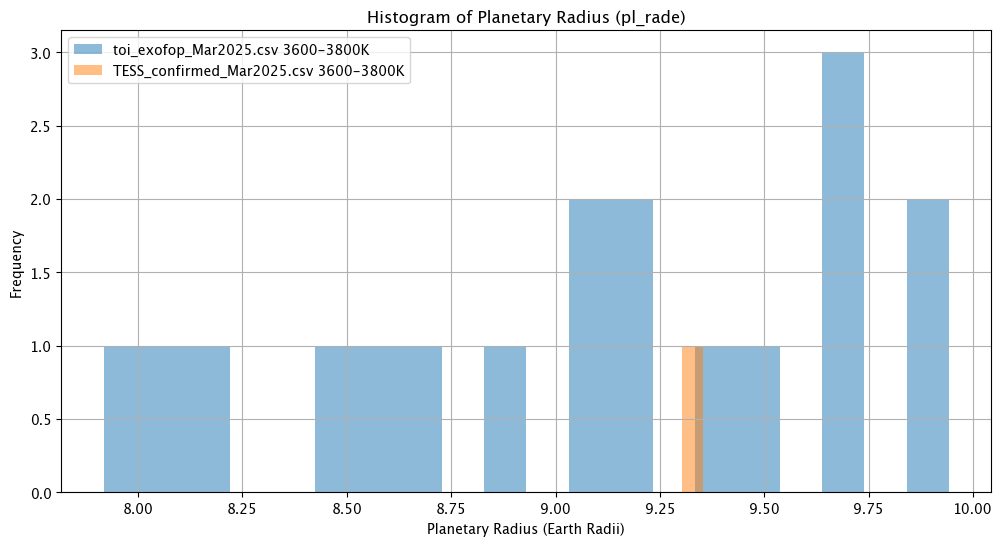

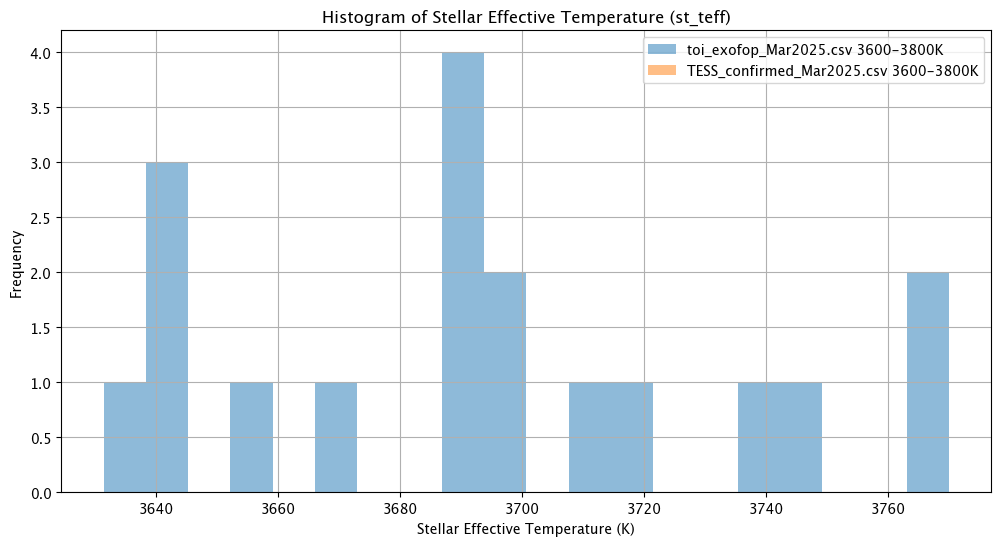

KeyError: 'pl_name'


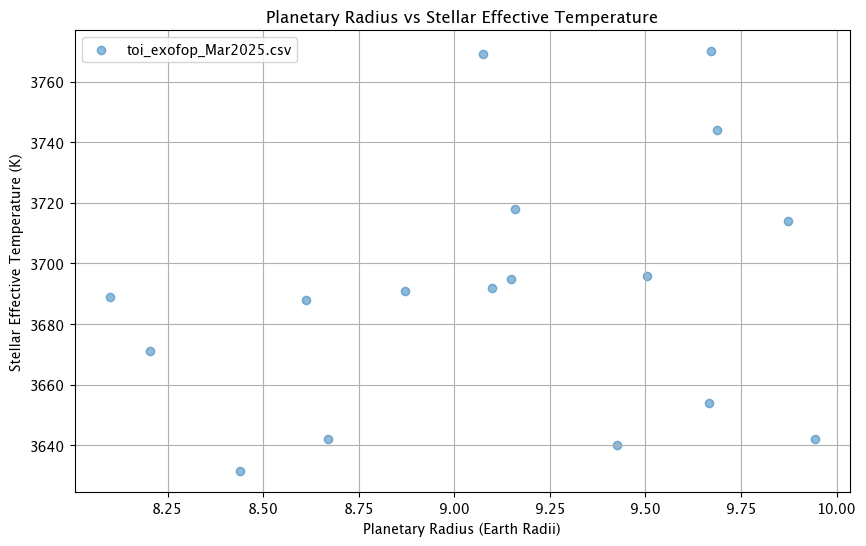

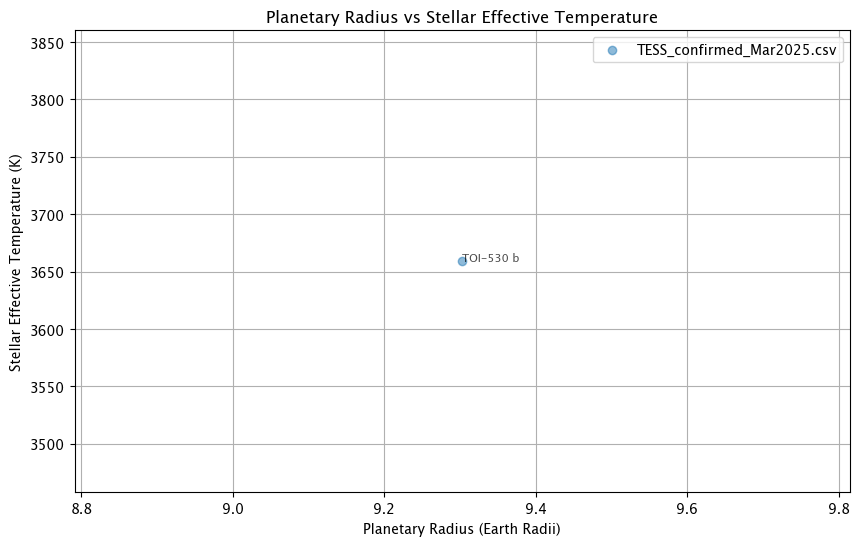

File 1: toi_exofop_Mar2025.csv
17 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.5882352941176471, P-value: 0.8888888888888888
KS Statistic for 'st_teff': 0.7058823529411765, P-value: 0.6666666666666667


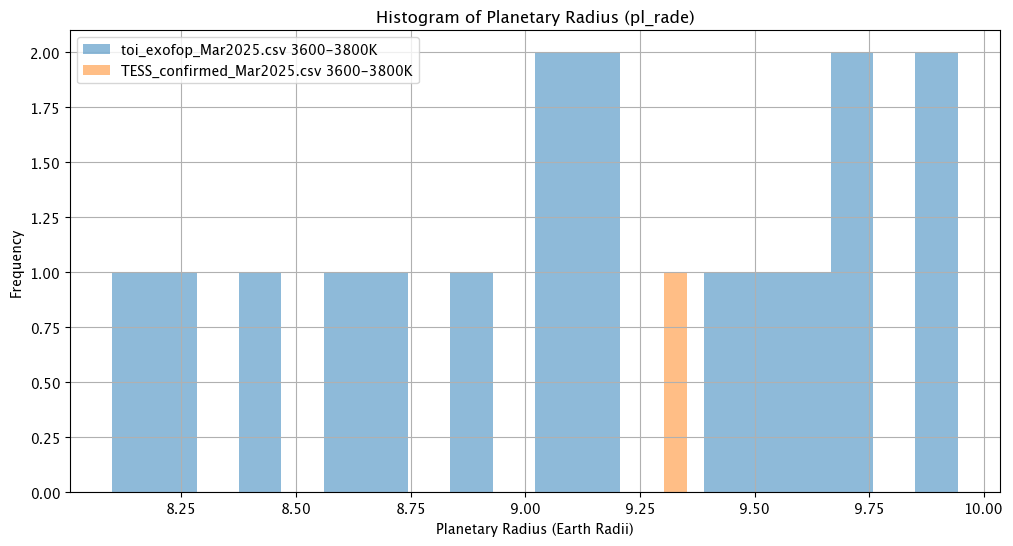

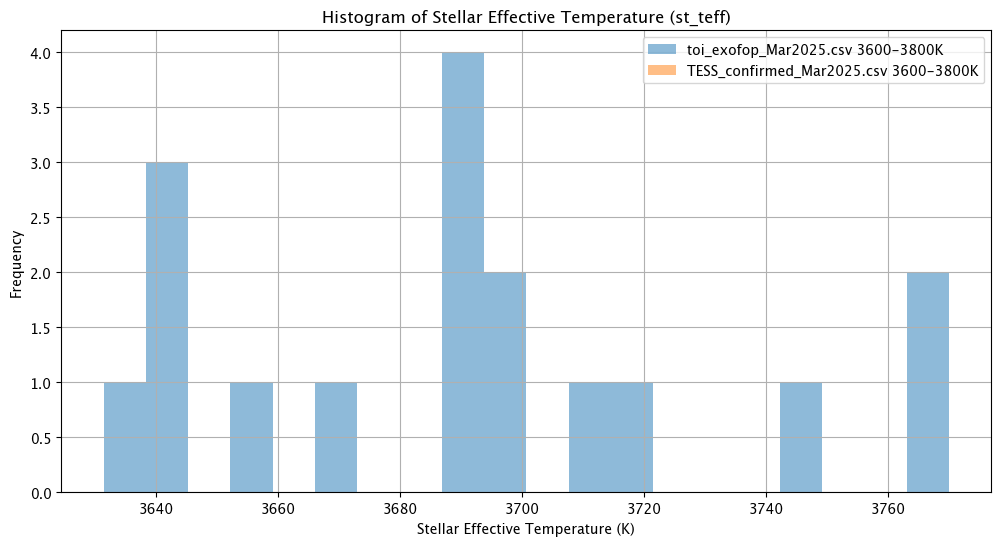

KeyError: 'pl_name'


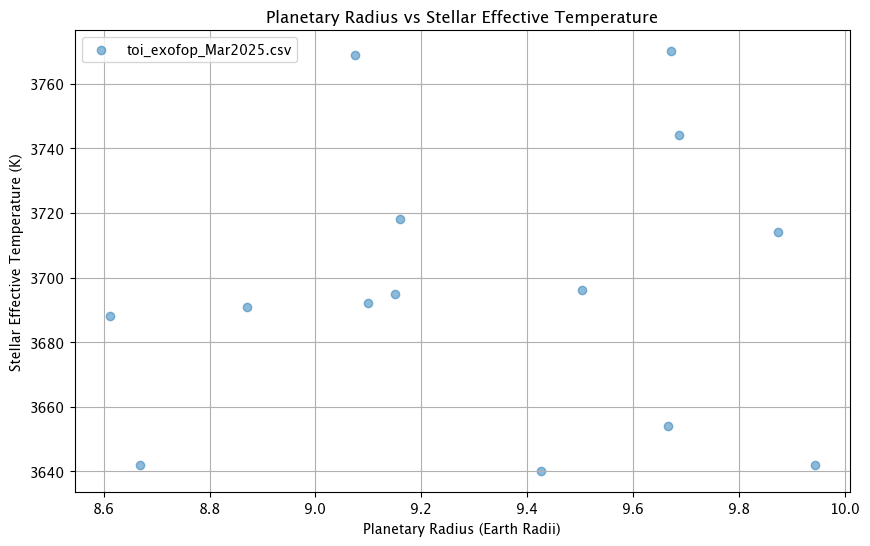

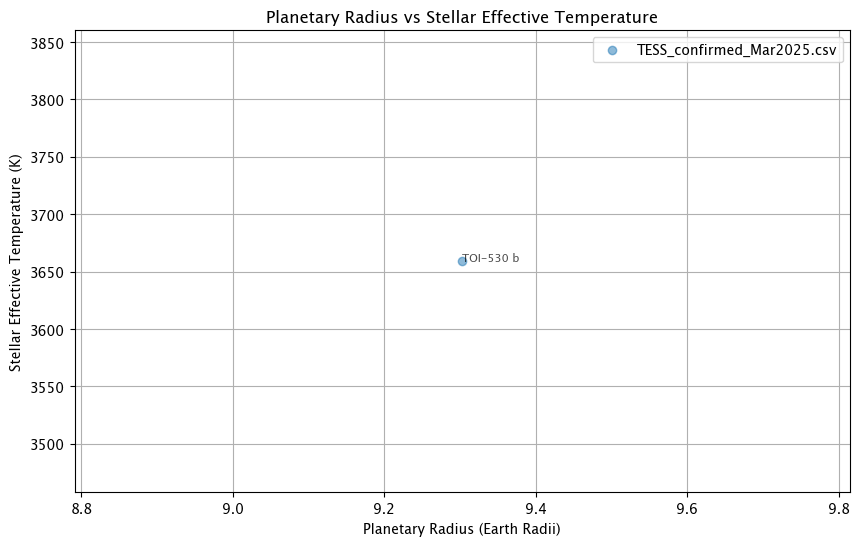

File 1: toi_exofop_Mar2025.csv
14 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.5, P-value: 1
KS Statistic for 'st_teff': 0.7142857142857143, P-value: 0.6666666666666667


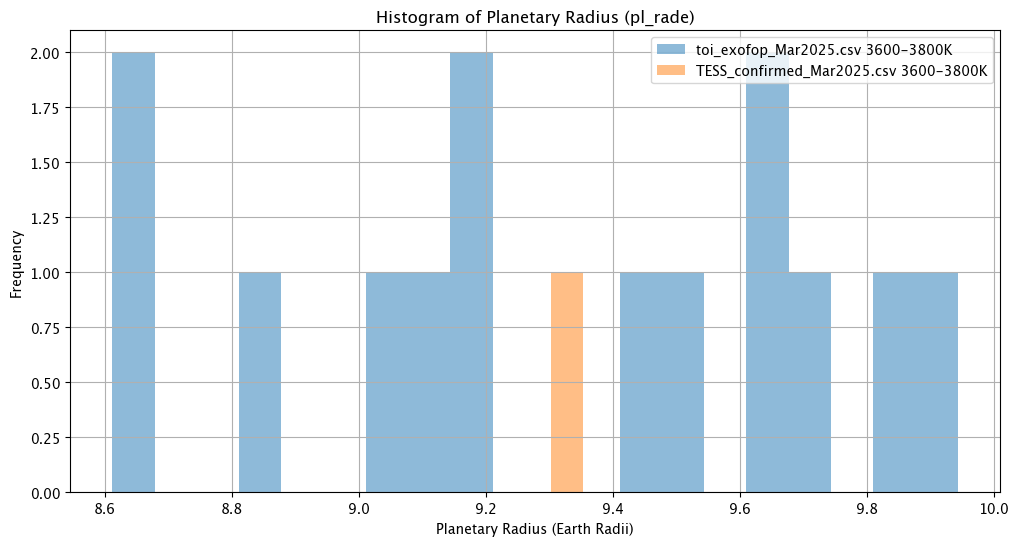

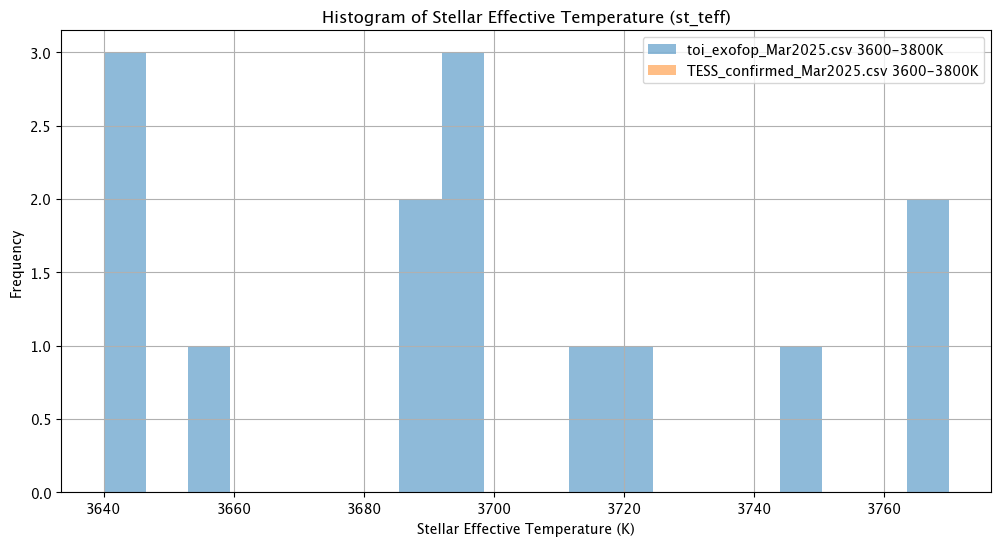

KeyError: 'pl_name'


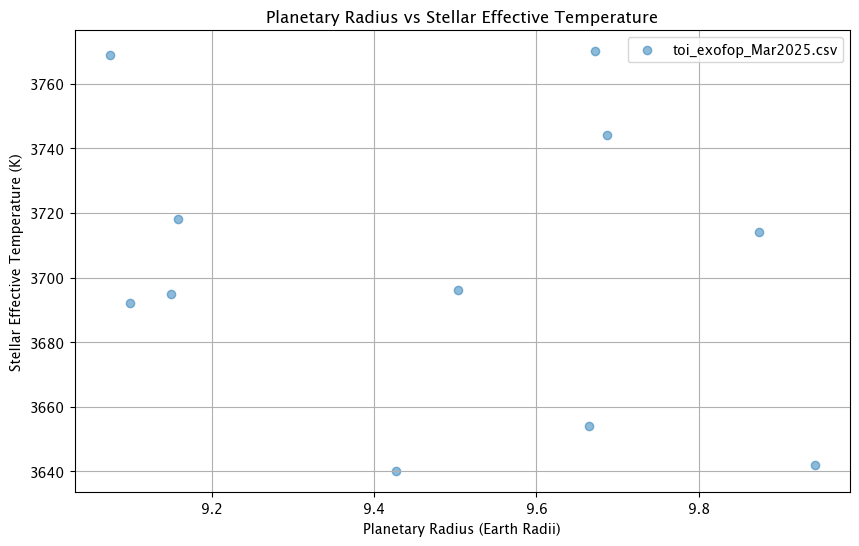

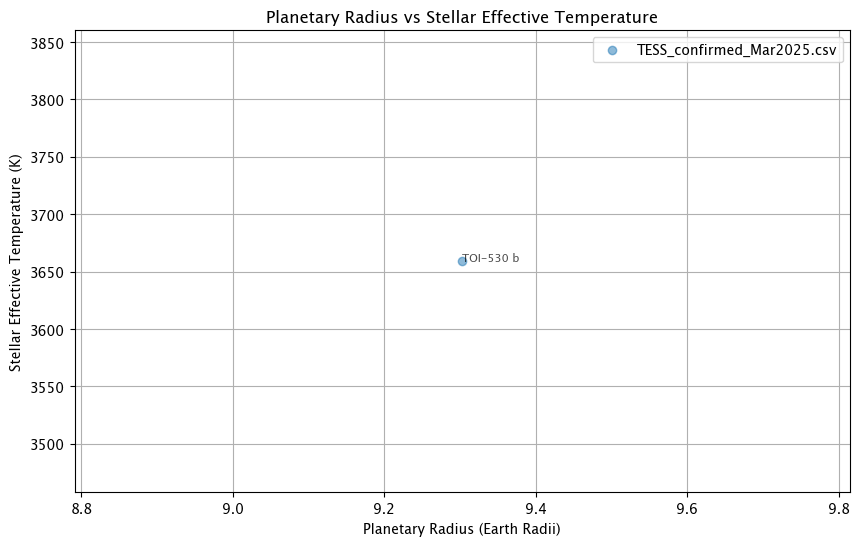

File 1: toi_exofop_Mar2025.csv
11 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
1 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.6363636363636364, P-value: 0.8333333333333334
KS Statistic for 'st_teff': 0.7272727272727273, P-value: 0.6666666666666667


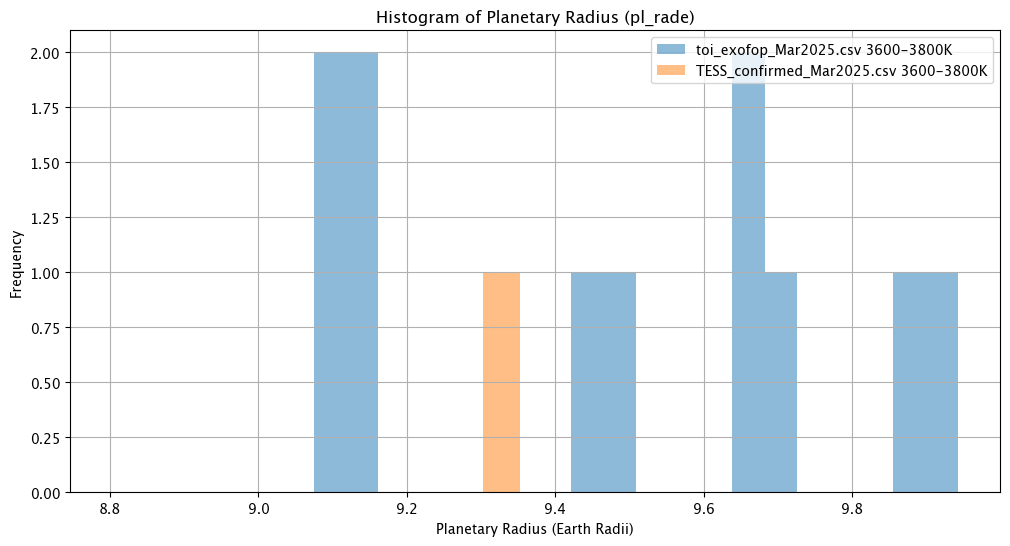

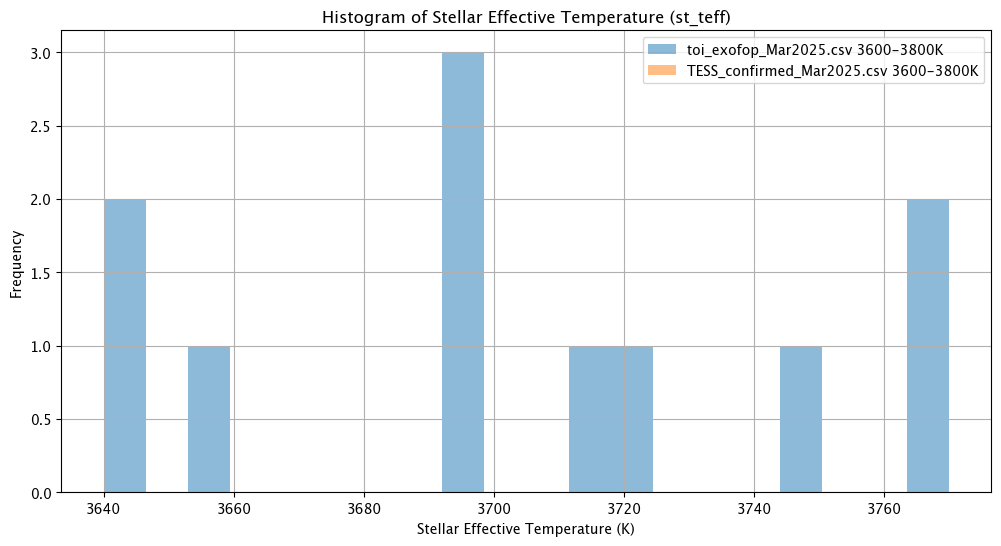

KeyError: 'pl_name'


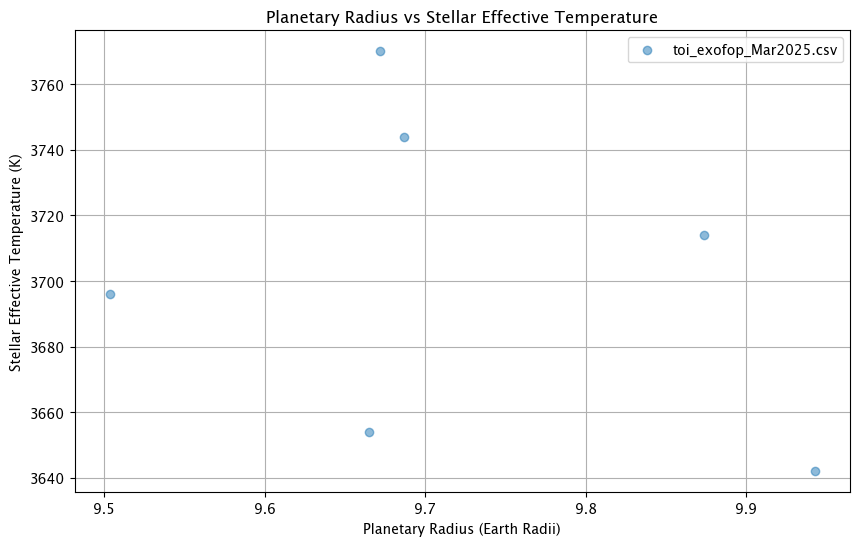

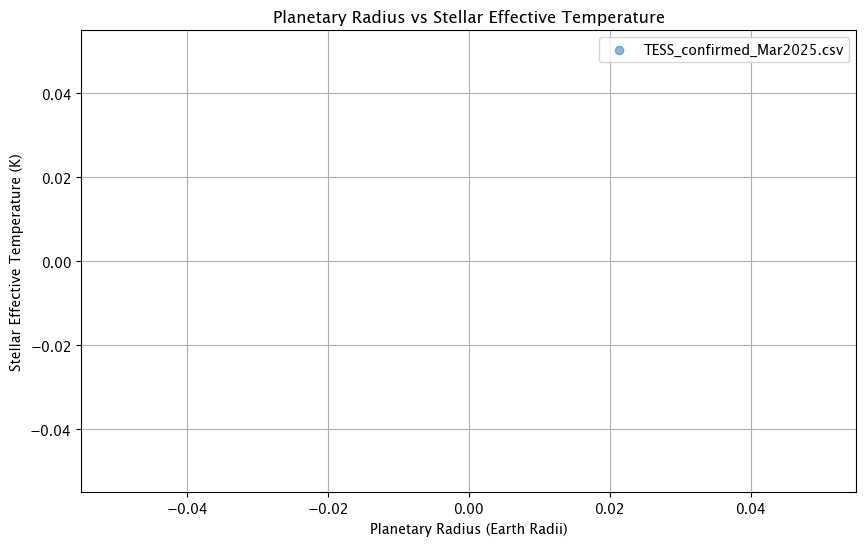

File 1: toi_exofop_Mar2025.csv
6 planets, Teff 3600 - 3800 K

File 2: TESS_confirmed_Mar2025.csv:
0 planets, Teff 3600 - 3800 K



ValueError: Data passed to ks_2samp must not be empty

In [14]:
import os

def perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2):
    # Define the CSV file path
    csv_file_path = 'results_ks_test_toi_vs_tessconfirmed.csv'

    # Check if the CSV file exists
    if os.path.exists(csv_file_path):
        # Load the existing results from the CSV file
        results_df = pd.read_csv(csv_file_path)
    else:
        # Create a new DataFrame if the CSV file does not exist
        results_df = pd.DataFrame(columns=['ks_statistic_rade', 'p_value_rade', 'ks_statistic_teff', 'p_value_teff', 'teff_min1', 'teff_max1', 'teff_min2', 'teff_max2', 'rad_min1', 'rad_max1', 'rad_min2', 'rad_max2', 'file_1_len', 'file_2_len'])

    ks_statistic_rade, p_value_rade, ks_statistic_teff, p_value_teff, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2, file_1_len, file_2_len = perform_ks_test('toi_exofop_Mar2025.csv', 0, 'TESS_confirmed_Mar2025.csv', 104, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

    new_row = {
        'ks_statistic_rade': ks_statistic_rade,
        'p_value_rade': p_value_rade,
        'ks_statistic_teff': ks_statistic_teff,
        'p_value_teff': p_value_teff,
        'teff_min1': teff_min1,
        'teff_max1': teff_max1,
        'teff_min2': teff_min2,
        'teff_max2': teff_max2,
        'rad_min1': rad_min1,
        'rad_max1': rad_max1,
        'rad_min2': rad_min2,
        'rad_max2': rad_max2,
        'file_1_len': file_1_len,
        'file_2_len': file_2_len
    }

    if not ((results_df['ks_statistic_rade'] == new_row['ks_statistic_rade']) & 
        (results_df['p_value_rade'] == new_row['p_value_rade']) & 
        (results_df['ks_statistic_teff'] == new_row['ks_statistic_teff']) & 
        (results_df['p_value_teff'] == new_row['p_value_teff']) & 
        (results_df['teff_min1'] == new_row['teff_min1']) & 
        (results_df['teff_max1'] == new_row['teff_max1']) & 
        (results_df['teff_min2'] == new_row['teff_min2']) & 
        (results_df['teff_max2'] == new_row['teff_max2']) & 
        (results_df['rad_min1'] == new_row['rad_min1']) & 
        (results_df['rad_max1'] == new_row['rad_max1']) & 
        (results_df['rad_min2'] == new_row['rad_min2']) & 
        (results_df['rad_max2'] == new_row['rad_max2'])).any():
        results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

    # Save the updated results to the CSV file
    results_df.to_csv(csv_file_path, index=False)
    return results_df

teff_min1 = 3600
teff_max1 = 3800
teff_min2 = 3600
teff_max2 = 3800

rad_max1 = 10
rad_max2 = 10

results_df = pd.DataFrame()

#LOOP
for rad_min in np.arange(0, 10, 0.5):
    rad_min1 = rad_min
    rad_min2 = rad_min
    results_df = perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

#SINGULAR
#results_df = perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

In [5]:
# Filter the results based on the defined ranges
def filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range):
    sample_results_df = results_df[(results_df['teff_min1'].between(*teff_min1_range)) & 
                                   (results_df['teff_max1'].between(*teff_max1_range)) & 
                                   (results_df['teff_min2'].between(*teff_min2_range)) & 
                                   (results_df['teff_max2'].between(*teff_max2_range)) & 
                                   (results_df['rad_min1'].between(*rad_min1_range)) & 
                                   (results_df['rad_max1'].between(*rad_max1_range)) & 
                                   (results_df['rad_min2'].between(*rad_min2_range)) & 
                                   (results_df['rad_max2'].between(*rad_max2_range))]

    # Print the ranges of effective temperature and planetary radius
    print("\nEffective Temperature and Planetary Radius Ranges:")
    print("Teff Min1:", sample_results_df['teff_min1'].unique())
    print("Teff Max1:", sample_results_df['teff_max1'].unique())
    print("Teff Min2:", sample_results_df['teff_min2'].unique())
    print("Teff Max2:", sample_results_df['teff_max2'].unique())
    print("Rad Min1:", sample_results_df['rad_min1'].unique())
    print("Rad Max1:", sample_results_df['rad_max1'].unique())
    print("Rad Min2:", sample_results_df['rad_min2'].unique())
    print("Rad Max2:", sample_results_df['rad_max2'].unique())

    # Create a new figure for the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['ks_statistic_rade'], marker='o', linestyle='-', color='b', label='ks_statistic_rade')
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['p_value_rade'], marker='o', linestyle='-', color='r', label='p_value_rade')
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['file_1_len']/100, marker='o', linestyle='-', color='g', label='file_1_len/100')
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['file_2_len']/100, marker='o', linestyle='-', color='y', label='file_2_len/100')
    plt.title('KS Statistic for Planetary Radius vs Minimum Radius')
    plt.xlabel('Minimum Planetary Radius (Earth Radii)')
    plt.ylabel('KS Statistic for Planetary Radius')
    plt.grid(True)
    plt.legend()
    plt.show()

    return sample_results_df



#How to descibe this plot? At 2 planetary radii, there is a peak in the ks statistic. That means that the samples are most different with this minimum radius


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3000]
Teff Max1: [3200]
Teff Min2: [3000]
Teff Max2: [3200]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]
Rad Max1: [10]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]
Rad Max2: [10]


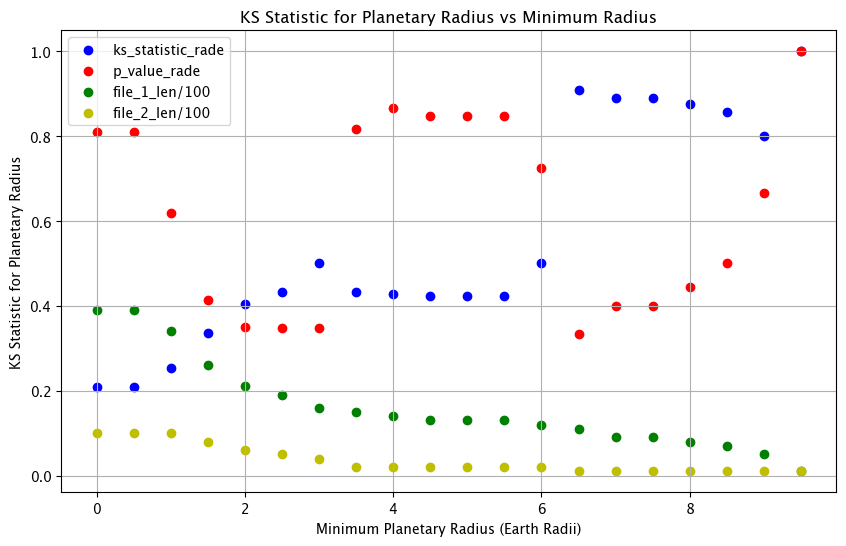

In [ ]:
teff_min1_range = (3000, 3001)
teff_max1_range = (3200, 3201)
teff_min2_range = (3000, 3201)
teff_max2_range = (3200, 3201)
rad_min1_range = (0, 10)
rad_max1_range = (10, 10.1)
rad_min2_range = (0, 10)
rad_max2_range = (10, 10.1)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

#at 2min planetary radius, the samples are most different, they are most similar without doing any radius cuts

#! could be that larger planets are more often FPs
#!high ks and p value both means large sample
#


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3200]
Teff Max1: [3400]
Teff Min2: [3200]
Teff Max2: [3400]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5]
Rad Max1: [10]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5]
Rad Max2: [10]


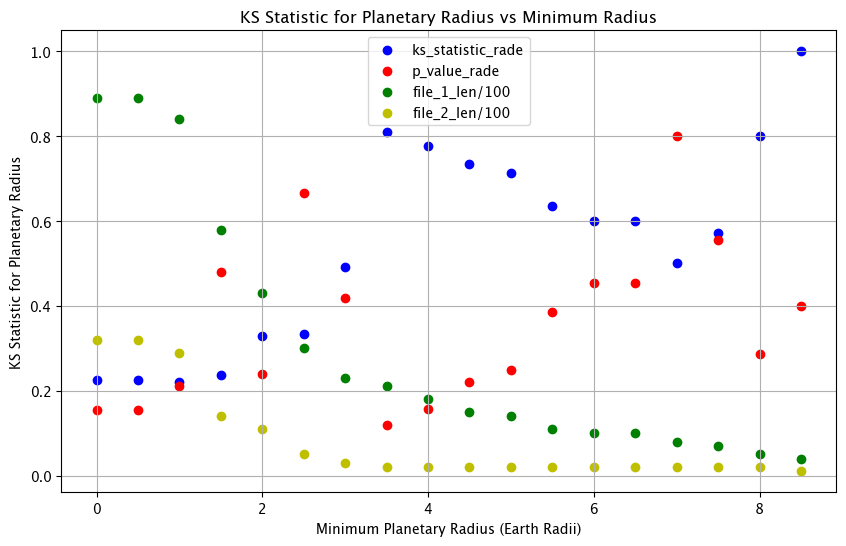

In [8]:
#print(results_df)
# Define the ranges for effective temperature and planetary radius
teff_min1_range = (3200, 3201)
teff_max1_range = (3400, 3401)
teff_min2_range = (3200, 3201)
teff_max2_range = (3400, 3401)
rad_min1_range = (0, 10)
rad_max1_range = (10, 10.1)
rad_min2_range = (0, 10)
rad_max2_range = (10, 10.1)


sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

#between these teff bins, the samples are most similar at minimum radius of 1, and it gets worse as you cut off more planets, but not linearly


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3400]
Teff Max1: [3600]
Teff Min2: [3400]
Teff Max2: [3600]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5]
Rad Max1: [10]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5]
Rad Max2: [10]


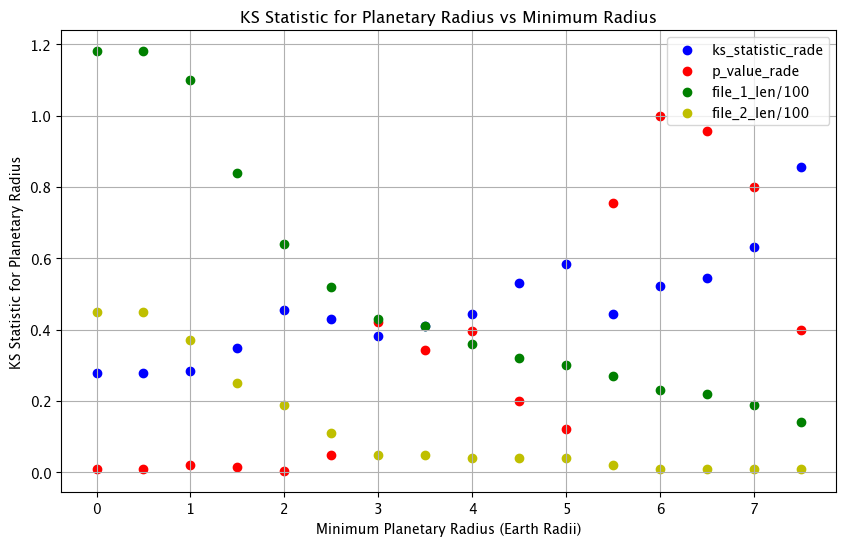

In [12]:
#print(results_df)
# Define the ranges for effective temperature and planetary radius
teff_min1_range = (3400, 3401)
teff_max1_range = (3600, 3601)
teff_min2_range = (3400, 3401)
teff_max2_range = (3600, 3601)
rad_min1_range = (0, 10)
rad_max1_range = (10, 10.1)
rad_min2_range = (0, 10)
rad_max2_range = (10, 10.1)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

#the sample are most different at minimum radius of 1.75 or 2.5, but are remakably similar at 2-2.25?? Why does it behave this way? There must be some planet sizes in this specific range that are shared between samples


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3600]
Teff Max1: [3800]
Teff Min2: [3600]
Teff Max2: [3800]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9. ]
Rad Max1: [10]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9. ]
Rad Max2: [10]


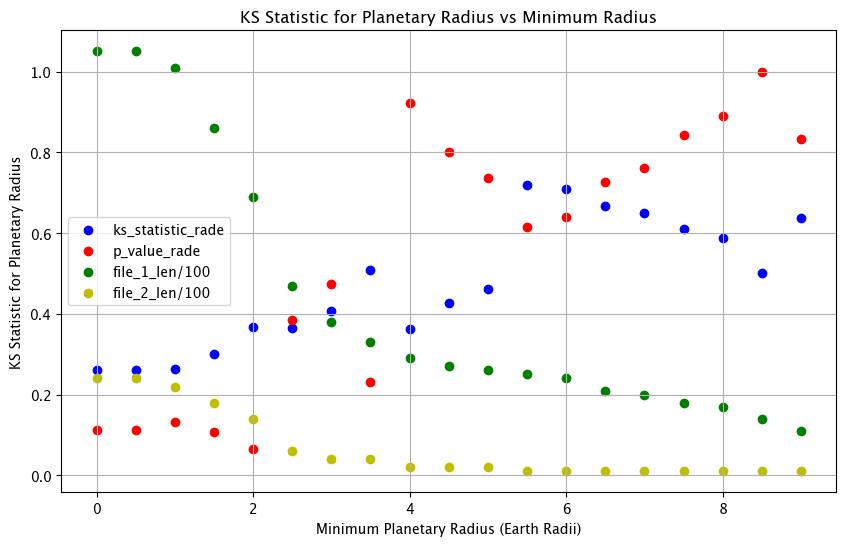

In [15]:
#print(results_df)
# Define the ranges for effective temperature and planetary radius
teff_min1_range = (3600, 3601)
teff_max1_range = (3800, 3801)
teff_min2_range = (3600, 3601)
teff_max2_range = (3800, 3801)
rad_min1_range = (0, 10)
rad_max1_range = (10, 10.1)
rad_min2_range = (0, 10)
rad_max2_range = (10, 10.1)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

#the sample are most different at minimum radius of 1.75 or 2.5, but are remakably similar at 2-2.25?? Why does it behave this way? There must be some planet sizes in this specific range that are shared between samples

In [ ]:
#look